CSV File Check

In [5]:
# AI use disclosure: OpenAI Codex was used for boilerplate generation
if (!file.exists("training_data.csv")) stop("Please upload training_data.csv.")
if (!file.exists("eval_data.csv")) stop("Please upload eval_data.csv.")

data manipulation and cleaning

In [9]:
# ============================================================================
# COMM3501 A4 - 1. Data Manipulation and Cleaning (R / Google Colab)
# ============================================================================
# AI use disclosure: OpenAI Codex was used for boilerplate generation,
# refactoring, and debugging. The student remains responsible for checking,
# interpreting, and reporting all results.
#
# Upload training_data.csv to the current Colab session before running.


# 1. Reproducibility and display settings ------------------------------------
set.seed(3501)
options(stringsAsFactors = FALSE, scipen = 999)


# 2. Read training_data.csv --------------------------------------------------
if (!file.exists("training_data.csv")) {
  stop("training_data.csv was not found. Please upload it and run the code again.")
}

# This is the line that directly reads the training CSV file.
raw <- read.csv(
  "training_data.csv",
  header = TRUE,
  stringsAsFactors = FALSE,
  check.names = FALSE,
  na.strings = c("", "NA")
)

cat(
  "Loaded training_data.csv:",
  format(nrow(raw), big.mark = ","), "rows x", ncol(raw), "columns\n"
)
print(head(raw))


# 3. Validate the assignment schema -----------------------------------------
expected_columns <- c(
  "CustomerID", "Churn", "MonthlyRevenue", "MonthlyMinutes",
  "TotalRecurringCharge", "OverageMinutes", "RoamingCalls", "DroppedCalls",
  "BlockedCalls", "UnansweredCalls", "CustomerCareCalls", "ThreewayCalls",
  "OutboundCalls", "InboundCalls", "DroppedBlockedCalls",
  "CallForwardingCalls", "CallWaitingCalls", "MonthsInService", "ActiveSubs",
  "ServiceArea", "Handsets", "CurrentEquipmentDays", "AgeHH1", "AgeHH2",
  "ChildrenInHH", "HandsetRefurbished", "HandsetWebCapable", "TruckOwner",
  "RVOwner", "BuysViaMailOrder", "RespondsToMailOffers", "OptOutMailings",
  "OwnsComputer", "HasCreditCard", "RetentionCalls",
  "RetentionOffersAccepted", "ReferralsMadeBySubscriber", "IncomeGroup",
  "OwnsMotorcycle", "MadeCallToRetentionTeam", "CreditRating", "PrizmCode",
  "Occupation", "MaritalStatus"
)

# Remove accidental spaces around column names.
names(raw) <- trimws(names(raw))

missing_columns <- setdiff(expected_columns, names(raw))
unexpected_columns <- setdiff(names(raw), expected_columns)

if (length(missing_columns) > 0 || length(unexpected_columns) > 0) {
  stop(
    paste0(
      "Schema mismatch. Missing columns: ",
      paste(missing_columns, collapse = ", "),
      "; unexpected columns: ",
      paste(unexpected_columns, collapse = ", ")
    )
  )
}

if (anyNA(raw$CustomerID)) {
  stop("CustomerID contains missing values; investigate before continuing.")
}

if (anyNA(raw$Churn)) {
  stop("Churn contains missing values; supervised training requires labels.")
}


# 4. Create a baseline data-quality audit -----------------------------------
audit_data <- function(data) {
  audit_rows <- lapply(names(data), function(column_name) {
    x <- data[[column_name]]
    is_numeric <- is.numeric(x)
    has_observed_value <- any(!is.na(x))

    data.frame(
      column = column_name,
      data_type = paste(class(x), collapse = "/"),
      missing_n = sum(is.na(x)),
      missing_pct = round(mean(is.na(x)) * 100, 3),
      unique_n = length(unique(x[!is.na(x)])),
      minimum = if (is_numeric && has_observed_value) min(x, na.rm = TRUE) else NA,
      maximum = if (is_numeric && has_observed_value) max(x, na.rm = TRUE) else NA,
      stringsAsFactors = FALSE
    )
  })

  do.call(rbind, audit_rows)
}

audit_before <- audit_data(raw)

cat("\nExact duplicate rows:", sum(duplicated(raw)), "\n")
cat("Duplicate CustomerIDs:", sum(duplicated(raw$CustomerID)), "\n")

cat("\nTarget distribution:\n")
target_count <- table(raw$Churn, useNA = "ifany")
target_distribution <- data.frame(
  Churn = names(target_count),
  Count = as.integer(target_count),
  Percent = round(as.integer(target_count) / nrow(raw) * 100, 3)
)
print(target_distribution, row.names = FALSE)

cat("\nColumns containing missing values before cleaning:\n")
print(
  audit_before[audit_before$missing_n > 0, ],
  row.names = FALSE
)


# 5. Clean and standardise values -------------------------------------------
# Work on a copy so that the original imported data remains unchanged.
df <- raw

# 5.1 Trim categorical text and convert blank strings to NA.
text_columns <- names(df)[vapply(df, is.character, logical(1))]

for (column_name in text_columns) {
  df[[column_name]] <- trimws(df[[column_name]])
  df[[column_name]][df[[column_name]] == ""] <- NA_character_
}


# 5.2 Validate and map Yes/No variables to 1/0.
binary_predictors <- c(
  "ChildrenInHH", "HandsetRefurbished", "HandsetWebCapable", "TruckOwner",
  "RVOwner", "BuysViaMailOrder", "RespondsToMailOffers", "OptOutMailings",
  "OwnsComputer", "HasCreditCard", "OwnsMotorcycle",
  "MadeCallToRetentionTeam"
)

yes_no_columns <- c("Churn", binary_predictors)

for (column_name in yes_no_columns) {
  invalid_values <- setdiff(unique(na.omit(df[[column_name]])), c("Yes", "No"))

  if (length(invalid_values) > 0) {
    stop(
      paste0(
        "Unexpected value(s) in ", column_name, ": ",
        paste(invalid_values, collapse = ", ")
      )
    )
  }

  df[[column_name]] <- ifelse(
    is.na(df[[column_name]]),
    NA_integer_,
    ifelse(df[[column_name]] == "Yes", 1L, 0L)
  )
}


# 5.3 Keep CustomerID as an identifier rather than a numerical predictor.
# CustomerID must be excluded from the future model feature matrix.
df$CustomerID <- as.character(df$CustomerID)


# 5.4 Confirm that measurement columns contain no hidden text.
categorical_columns <- c(
  "CustomerID", "ServiceArea", "PrizmCode", "Occupation", "MaritalStatus"
)

numeric_columns <- setdiff(names(df), categorical_columns)

for (column_name in numeric_columns) {
  original_non_missing <- !is.na(df[[column_name]])
  converted_values <- suppressWarnings(as.numeric(df[[column_name]]))

  if (any(original_non_missing & is.na(converted_values))) {
    stop(paste0("Hidden non-numeric value found in ", column_name, "."))
  }

  df[[column_name]] <- converted_values
}


# 5.5 Treat zero household ages as unreported, while preserving indicators.
# Zero is not a plausible reported age. The indicator retains the information
# that the age was absent instead of silently treating zero as a real age.
for (column_name in c("AgeHH1", "AgeHH2")) {
  indicator_name <- paste0(column_name, "_Missing")
  df[[indicator_name]] <- as.integer(is.na(df[[column_name]]) | df[[column_name]] == 0)
  df[[column_name]][df[[column_name]] == 0] <- NA_real_
}


# 5.6 Retain unusual billing values and create transparent warning flags.
# Negative values could represent refunds or billing credits, so they are not
# automatically deleted or replaced without supporting business information.
df$MonthlyRevenue_Negative <- as.integer(
  !is.na(df$MonthlyRevenue) & df$MonthlyRevenue < 0
)

df$TotalRecurringCharge_Negative <- as.integer(
  !is.na(df$TotalRecurringCharge) & df$TotalRecurringCharge < 0
)


# 5.7 Remove exact duplicate rows only.
exact_duplicates_removed <- sum(duplicated(df))
df <- df[!duplicated(df), , drop = FALSE]
row.names(df) <- NULL

# Do not silently choose one record when CustomerID is duplicated.
if (anyDuplicated(df$CustomerID) > 0) {
  duplicated_ids <- unique(df$CustomerID[duplicated(df$CustomerID)])
  stop(
    paste0(
      "Duplicate CustomerIDs require investigation. Examples: ",
      paste(head(duplicated_ids, 10), collapse = ", ")
    )
  )
}


# 6. Validate and summarise the cleaned data --------------------------------
stopifnot(all(na.omit(df$Churn) %in% c(0, 1)))
stopifnot(!anyNA(df$CustomerID))
stopifnot(!anyNA(df$Churn))
stopifnot(anyDuplicated(df$CustomerID) == 0)

audit_after <- audit_data(df)

quality_summary <- data.frame(
  check = c(
    "source_rows",
    "source_columns",
    "cleaned_rows",
    "cleaned_columns",
    "exact_duplicates_removed",
    "duplicate_customer_ids",
    "churn_yes_n",
    "churn_yes_pct",
    "remaining_missing_cells",
    "negative_monthly_revenue_n",
    "negative_total_recurring_charge_n"
  ),
  value = c(
    nrow(raw),
    ncol(raw),
    nrow(df),
    ncol(df),
    exact_duplicates_removed,
    sum(duplicated(df$CustomerID)),
    sum(df$Churn == 1),
    round(mean(df$Churn == 1) * 100, 3),
    sum(is.na(df)),
    sum(df$MonthlyRevenue_Negative),
    sum(df$TotalRecurringCharge_Negative)
  )
)

cat("\nCleaning summary:\n")
print(quality_summary, row.names = FALSE)

cat("\nRemaining missing values:\n")
print(
  audit_after[audit_after$missing_n > 0, ],
  row.names = FALSE
)

cat("\nCleaned-data preview:\n")
print(head(df))


# 7. Save reproducible outputs ----------------------------------------------
write.csv(
  df,
  "training_data_cleaned.csv",
  row.names = FALSE,
  na = ""
)

write.csv(
  audit_before,
  "audit_before_cleaning.csv",
  row.names = FALSE,
  na = ""
)

write.csv(
  audit_after,
  "audit_after_cleaning.csv",
  row.names = FALSE,
  na = ""
)

write.csv(
  quality_summary,
  "cleaning_summary.csv",
  row.names = FALSE,
  na = ""
)

cleaning_notes <- c(
  "Target mapping: No = 0; Yes = 1.",
  "Binary predictor mapping: No = 0; Yes = 1.",
  "CustomerID is retained only as an identifier and must be excluded from modelling.",
  "AgeHH1/AgeHH2 values equal to zero are treated as unreported; indicator columns preserve this information.",
  "Negative billing values are retained and flagged rather than automatically deleted.",
  "Remaining predictor missing values must be imputed later inside the model pipeline after data splitting to avoid leakage."
)

writeLines(
  cleaning_notes,
  "cleaning_method_notes.txt"
)

cat(
  "\nSaved cleaned data to:\n",
  "training_data_cleaned.csv",
  "\nThe original training_data.csv was not modified.\n"
)

Loaded training_data.csv: 30,000 rows x 44 columns
  CustomerID Churn MonthlyRevenue MonthlyMinutes TotalRecurringCharge
1    6225263    No          54.47            206                   41
2    6108943    No          72.73           1090                   69
3    6044867    No          54.55            551                   45
4    6104839   Yes          34.77            100                   30
5    6280759    No          55.96            444                   60
6    6300327    No          84.61           1034                   65
  OverageMinutes RoamingCalls DroppedCalls BlockedCalls UnansweredCalls
1             43          0.0          1.0          0.0             9.0
2              0          0.0         30.7          2.0            83.3
3             37          0.0         23.0          3.7            68.0
4              2          3.6          2.0          0.3             9.7
5              0          0.0          8.0          0.7            39.3
6             99          0

exploratory data analysis

Overall churn rate: 28.8% 


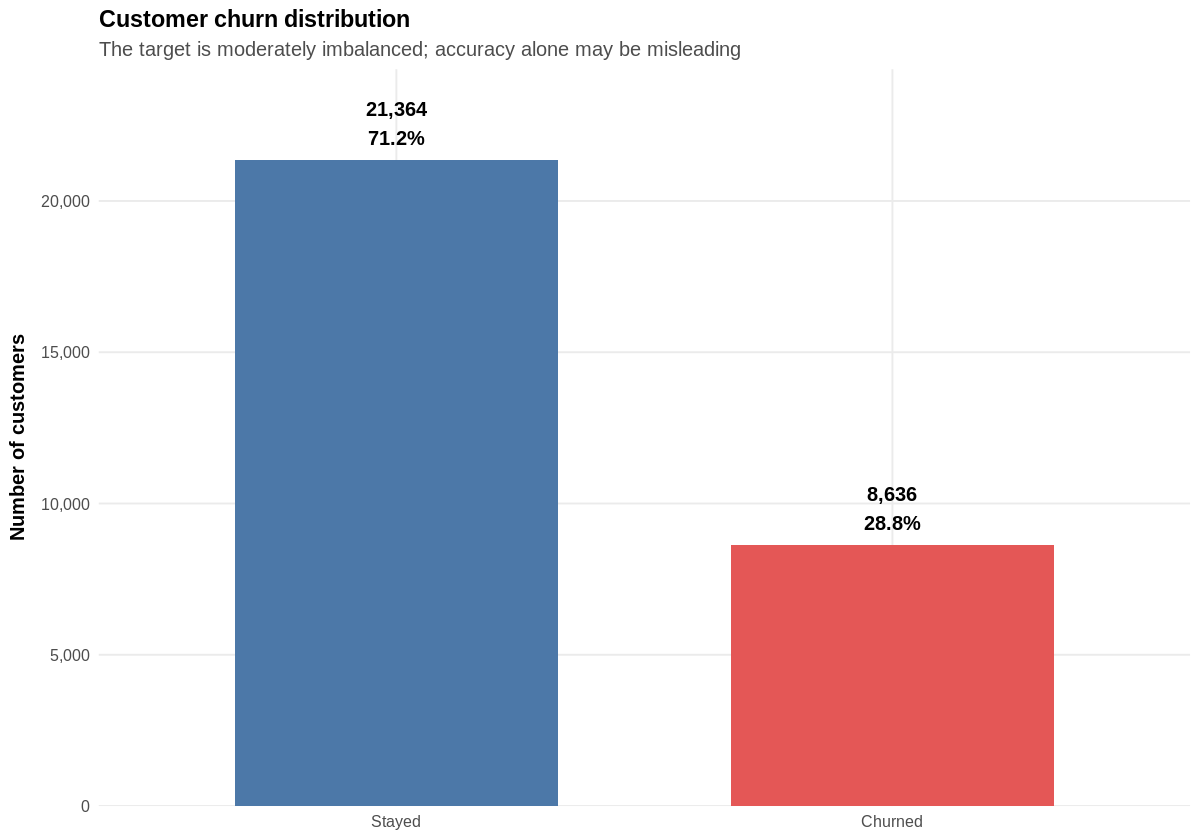

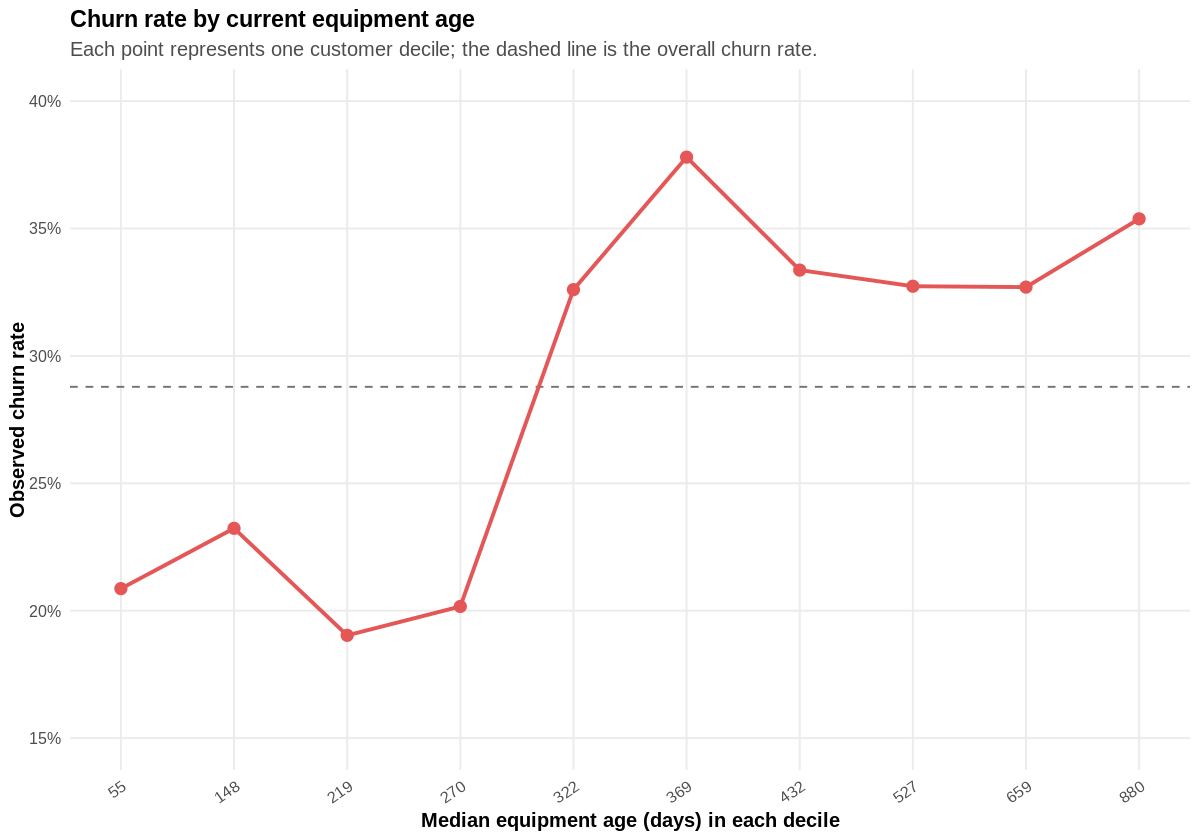

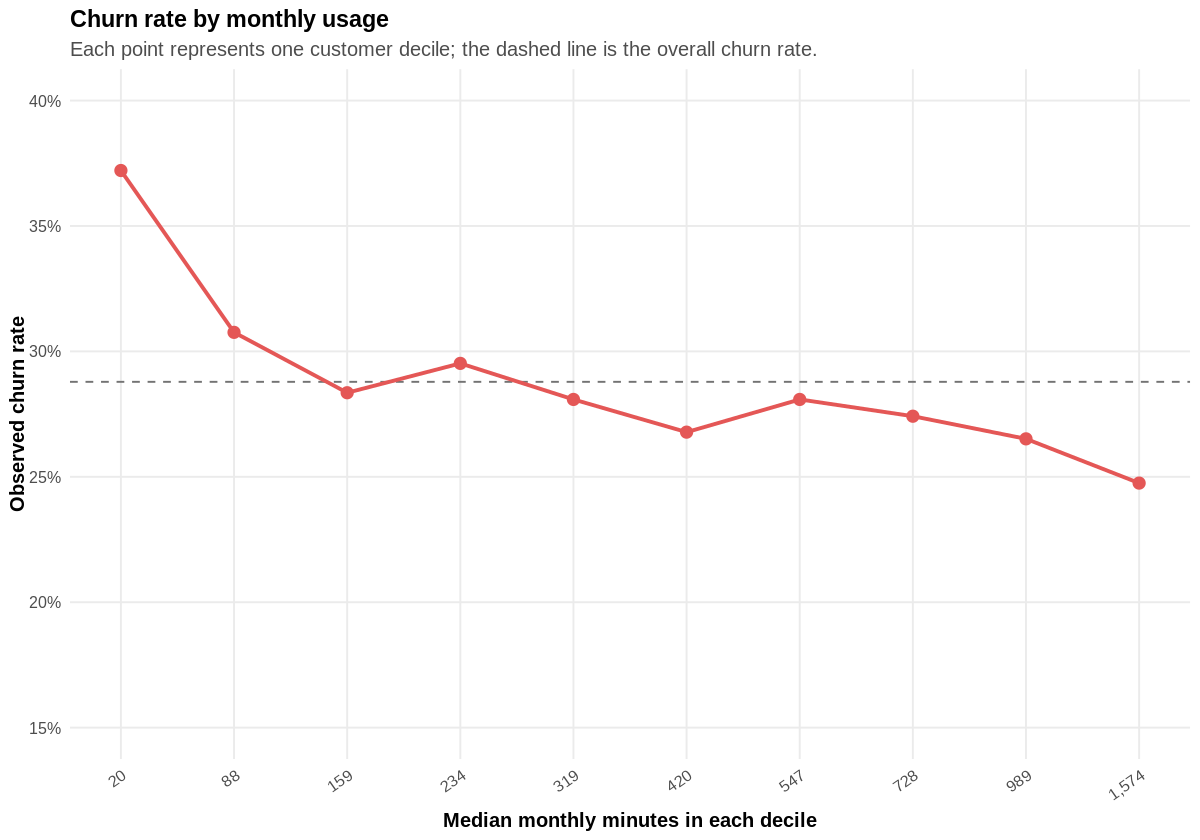

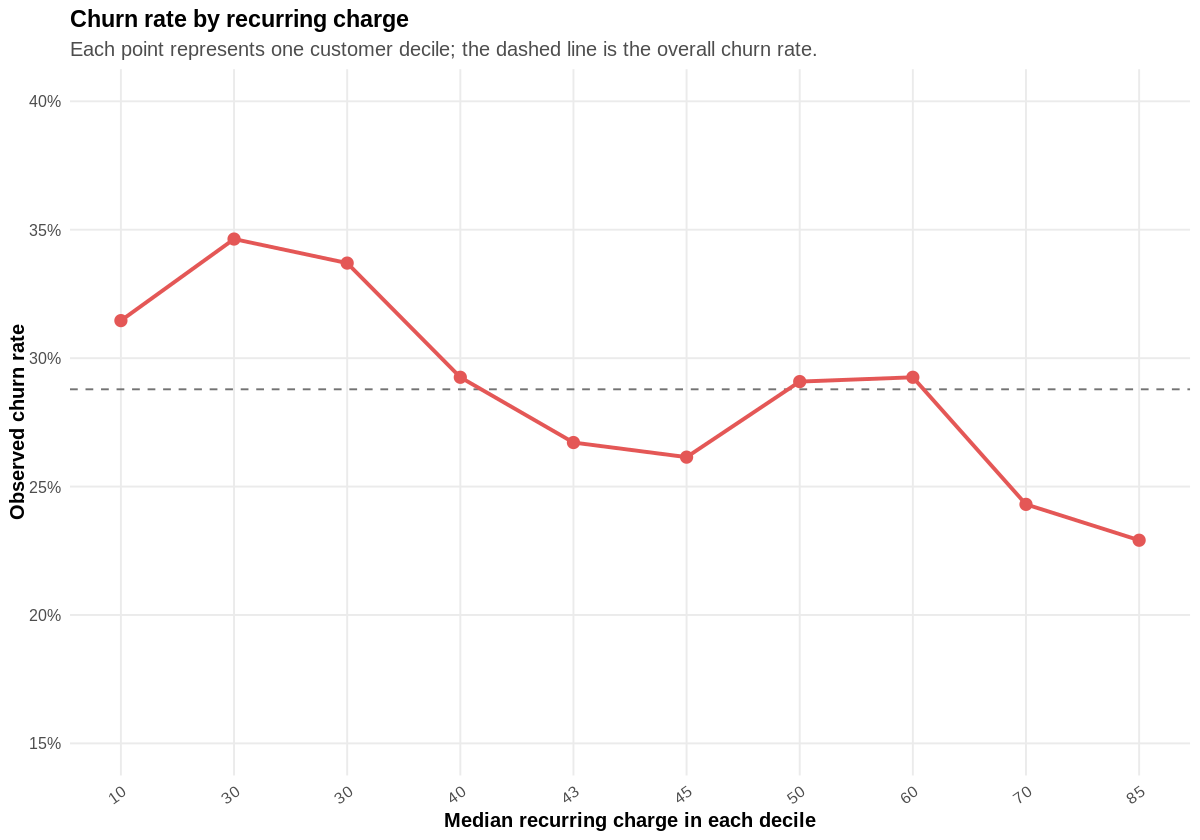

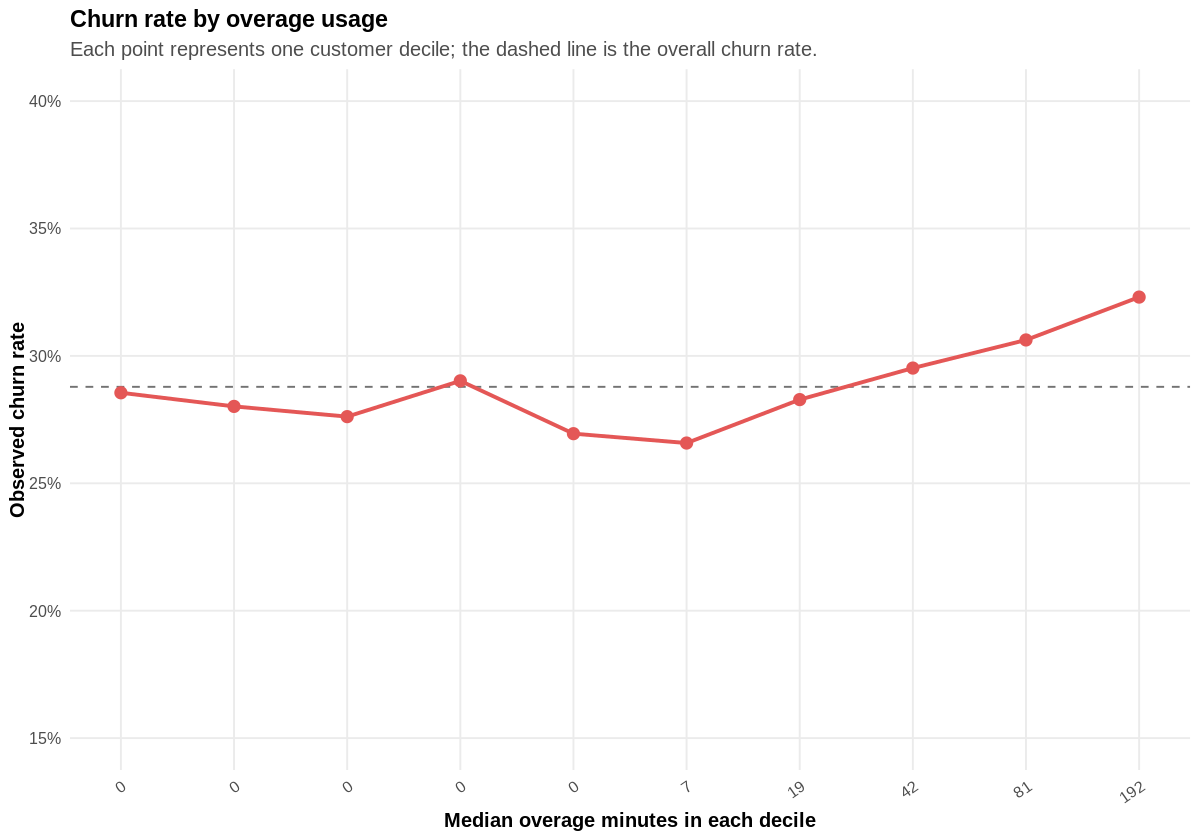

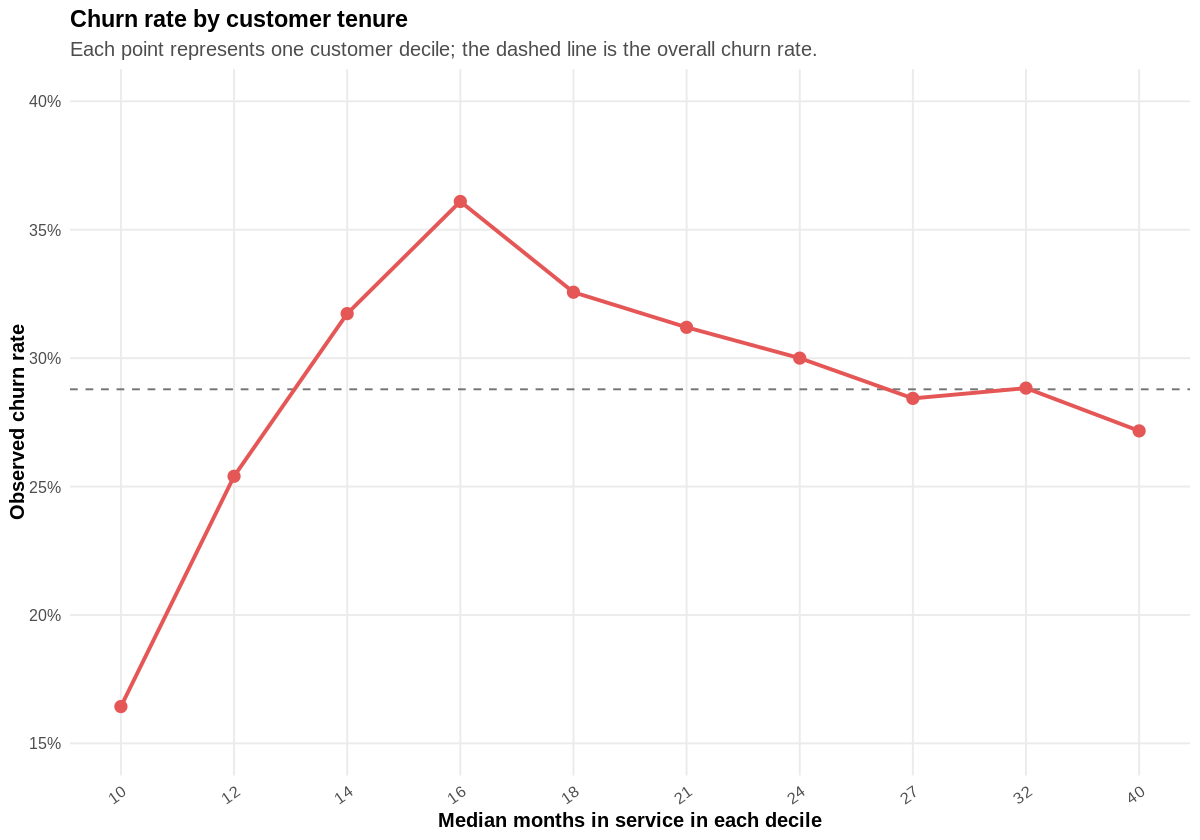

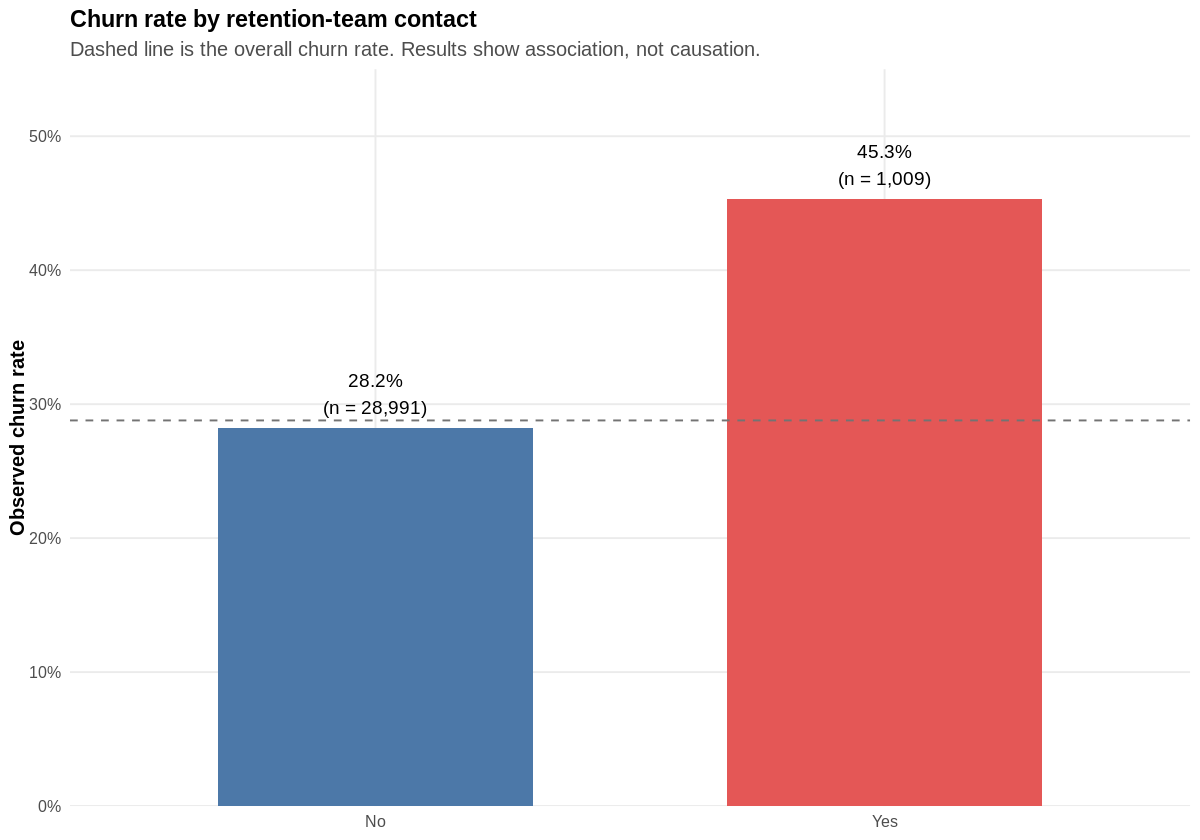

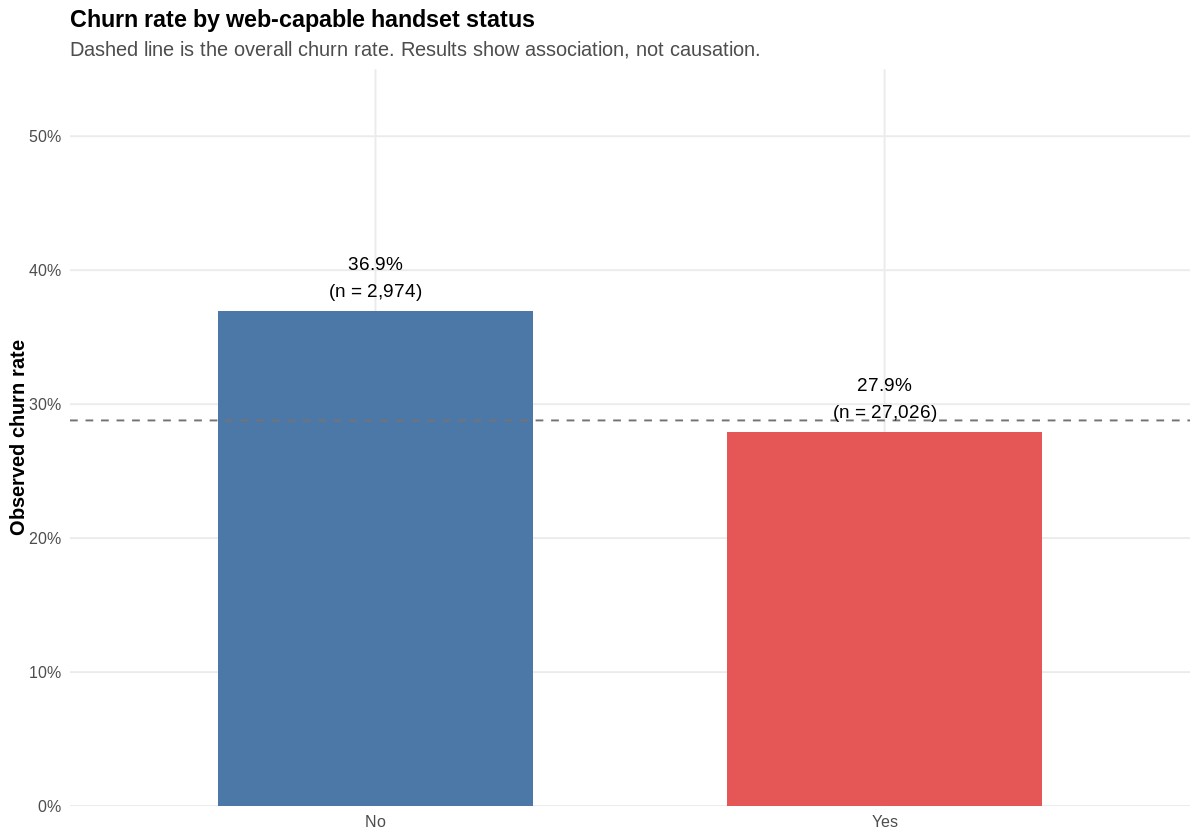

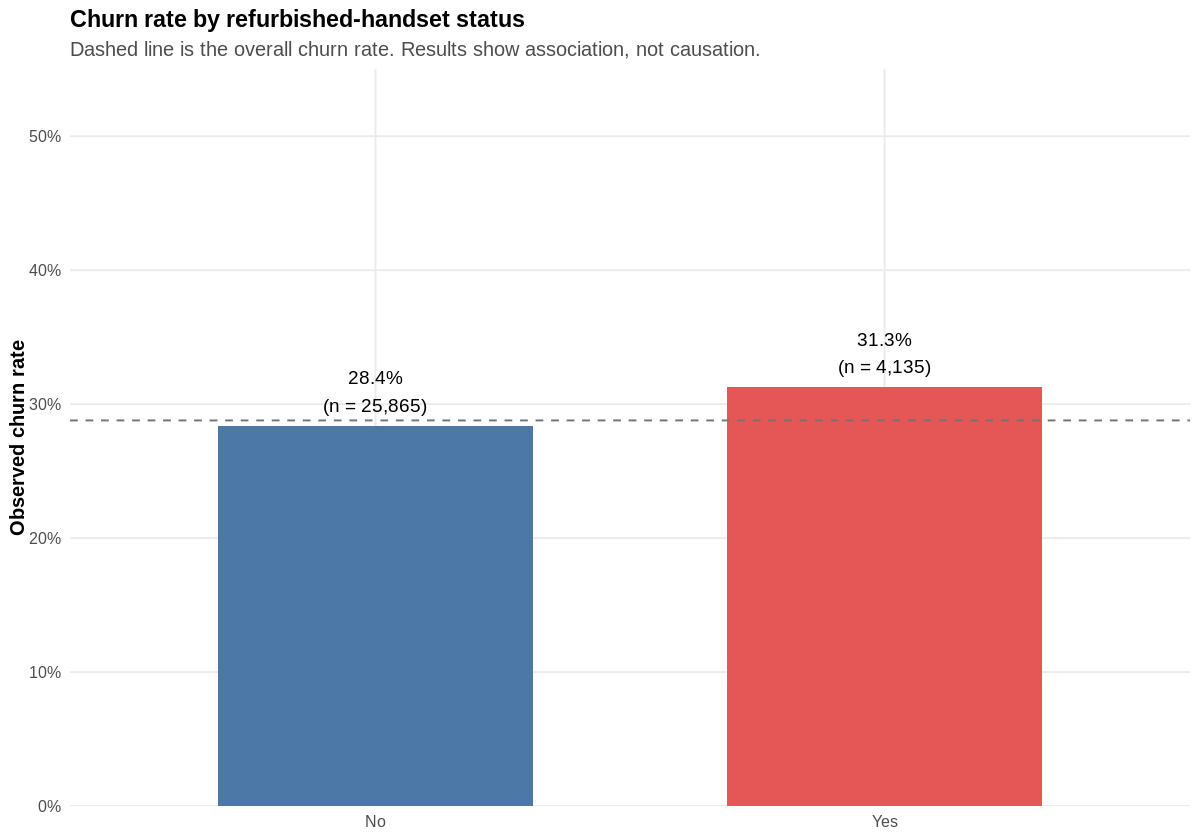

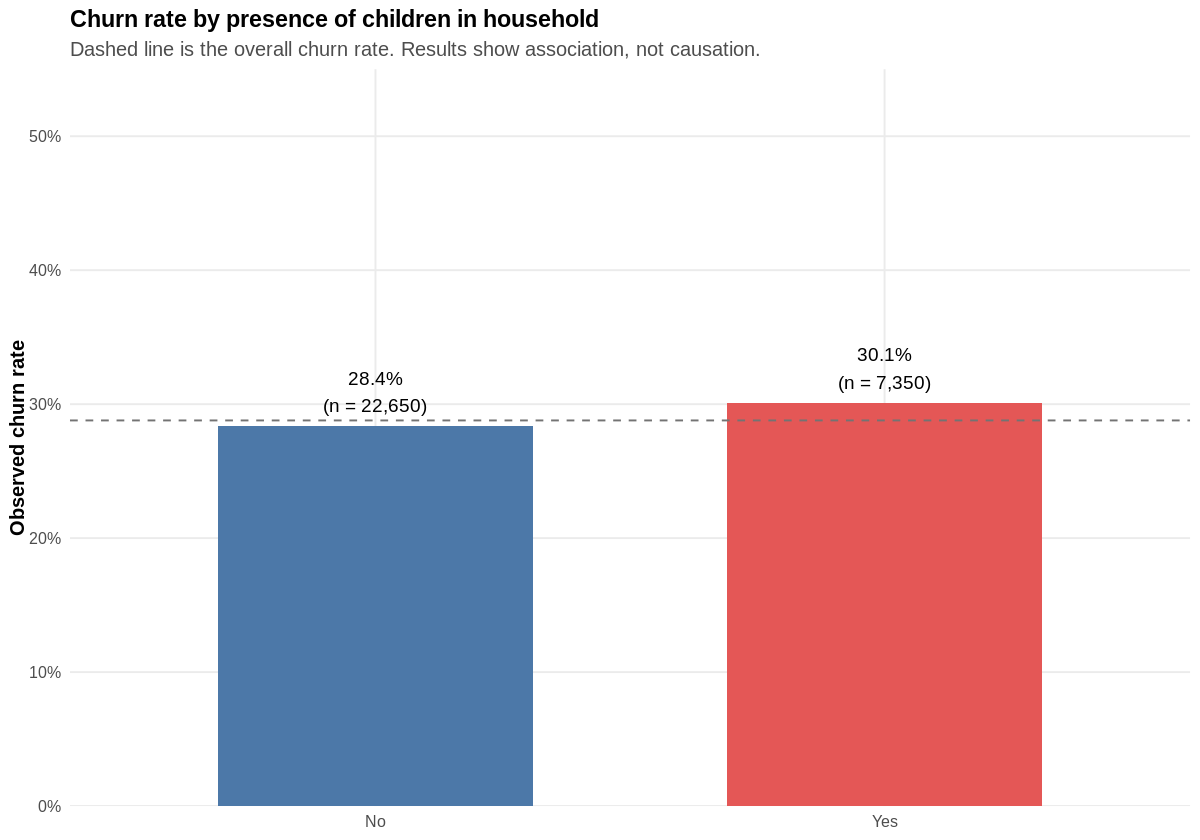

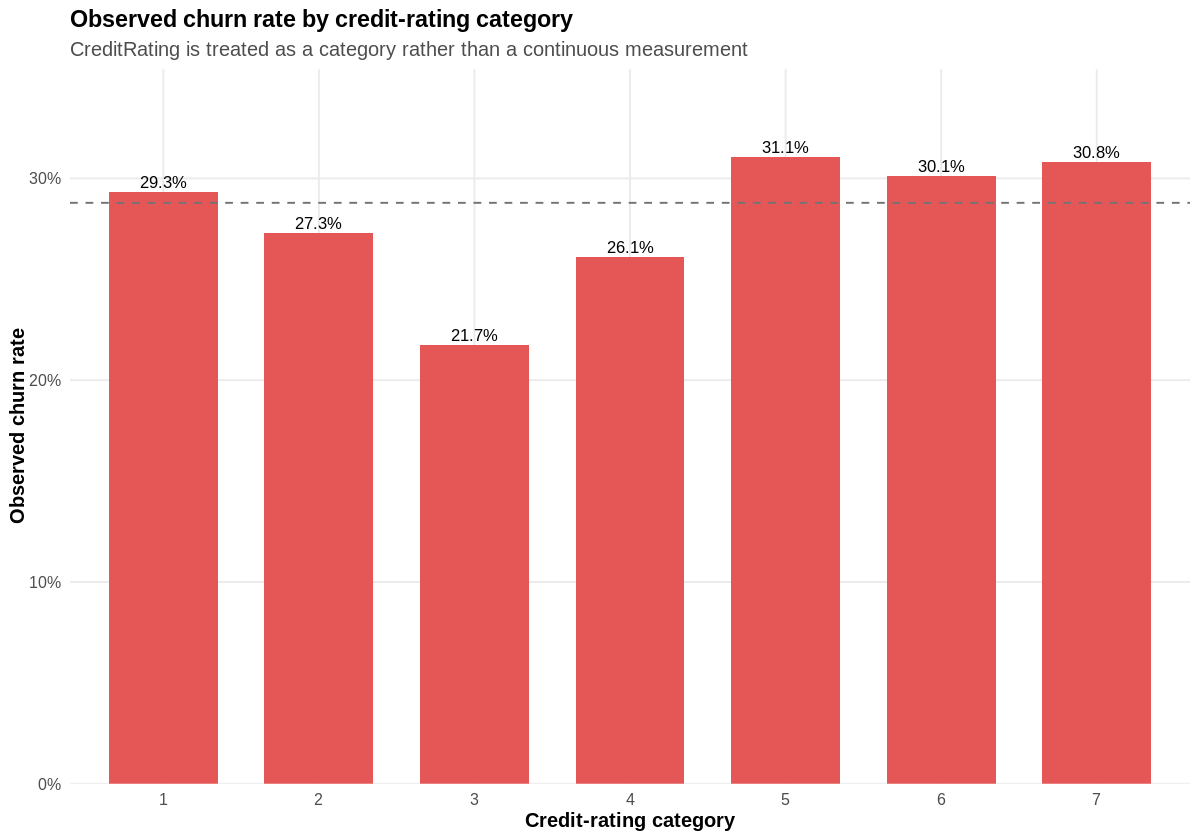


Key descriptive results for report drafting:
# A tibble: 2 × 4
  Variable                Level Customers Churn_Rate
  <chr>                   <chr>     <int>      <dbl>
1 MadeCallToRetentionTeam No        28991      0.282
2 MadeCallToRetentionTeam Yes        1009      0.453
# A tibble: 2 × 4
  Variable          Level Customers Churn_Rate
  <chr>             <chr>     <int>      <dbl>
1 HandsetWebCapable No         2974      0.369
2 HandsetWebCapable Yes       27026      0.279
              Variable Stayed_Mean Churned_Mean Stayed_Median Churned_Median
1 CurrentEquipmentDays    377.1431     435.8632           323            381
  Mean_Difference
1        58.72015

EDA outputs saved as PNG and CSV files. Interpret these as descriptive associations, not causal effects.


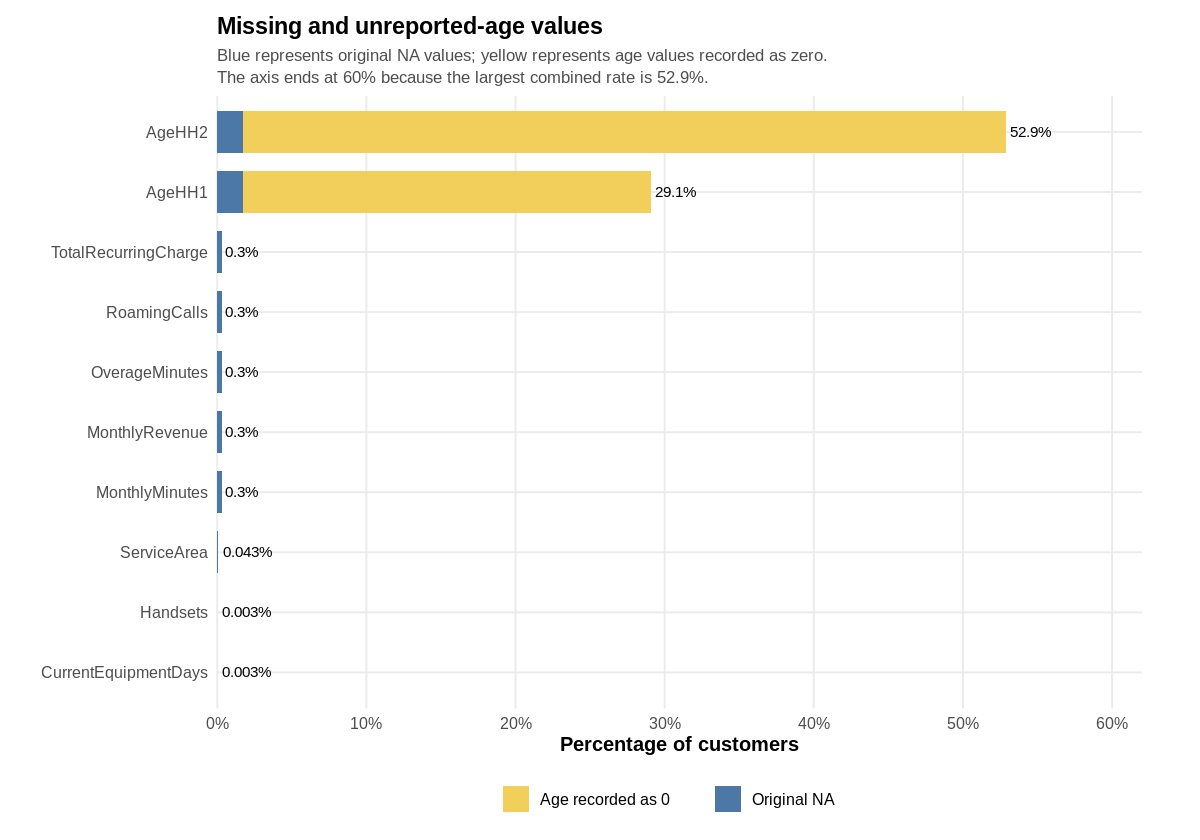

In [10]:
# ============================================================================
# COMM3501 A4 - 2. Exploratory Data Analysis (R / Google Colab)
# ============================================================================
# Run this code after 01_data_manipulation_cleaning_colab.R.
# It uses the cleaned data frame named `df` already available in memory.
#
# AI use disclosure: OpenAI Codex was used for boilerplate generation,
# refactoring, and debugging. The student remains responsible for checking,
# interpreting, and reporting all results.


# 1. Packages ----------------------------------------------------------------
required_packages <- c("ggplot2", "dplyr", "tidyr", "scales")
missing_packages <- required_packages[
  !vapply(required_packages, requireNamespace, logical(1), quietly = TRUE)
]

if (length(missing_packages) > 0) {
  install.packages(missing_packages, repos = "https://cloud.r-project.org")
}

suppressPackageStartupMessages({
  library(ggplot2)
  library(dplyr)
  library(tidyr)
  library(scales)
})

# Make plots wide enough to display complete titles inside Colab.
options(repr.plot.width = 10, repr.plot.height = 7, repr.plot.res = 120)


# 2. Confirm that the cleaned data exists ------------------------------------
df_is_available <- exists(
  "df",
  envir = .GlobalEnv,
  inherits = FALSE
) && is.data.frame(get("df", envir = .GlobalEnv, inherits = FALSE))

if (!df_is_available) {
  stop("The cleaned data frame `df` was not found. Run the cleaning code first.")
}

df <- get("df", envir = .GlobalEnv, inherits = FALSE)

if (!all(c("CustomerID", "Churn") %in% names(df))) {
  stop("The object `df` does not contain the required CustomerID and Churn columns.")
}

if (!all(na.omit(df$Churn) %in% c(0, 1))) {
  stop("Churn must be coded as 0 = stayed and 1 = churned.")
}

eda <- df
eda$ChurnLabel <- factor(
  eda$Churn,
  levels = c(0, 1),
  labels = c("Stayed", "Churned")
)

overall_churn_rate <- mean(eda$Churn, na.rm = TRUE)
cat("Overall churn rate:", percent(overall_churn_rate, accuracy = 0.1), "\n")


# Shared report theme ---------------------------------------------------------
report_theme <- theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold", size = 14),
    plot.subtitle = element_text(color = "grey30"),
    axis.title = element_text(face = "bold"),
    panel.grid.minor = element_blank(),
    legend.position = "bottom",
    strip.text = element_text(face = "bold")
  )

colour_stayed <- "#4C78A8"
colour_churned <- "#E45756"
colour_rate <- "#E45756"


# 3. Figure 1 - Target distribution -----------------------------------------
target_summary <- eda %>%
  count(ChurnLabel, name = "Customers") %>%
  mutate(Share = Customers / sum(Customers))

plot_target <- ggplot(
  target_summary,
  aes(x = ChurnLabel, y = Customers, fill = ChurnLabel)
) +
  geom_col(width = 0.65, show.legend = FALSE) +
  geom_text(
    aes(label = paste0(comma(Customers), "\n", percent(Share, accuracy = 0.1))),
    vjust = -0.35,
    fontface = "bold"
  ) +
  scale_fill_manual(values = c("Stayed" = colour_stayed, "Churned" = colour_churned)) +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.14))) +
  labs(
    title = "Customer churn distribution",
    subtitle = "The target is moderately imbalanced; accuracy alone may be misleading",
    x = NULL,
    y = "Number of customers"
  ) +
  report_theme

print(plot_target)
ggsave("eda_01_churn_distribution.png", plot_target, width = 7.2, height = 4.8, dpi = 300)


# 4. Numeric summary table by churn status ----------------------------------
numeric_variables <- c(
  "MonthlyRevenue", "MonthlyMinutes", "TotalRecurringCharge",
  "OverageMinutes", "RoamingCalls", "DroppedCalls", "BlockedCalls",
  "UnansweredCalls", "CustomerCareCalls", "OutboundCalls", "InboundCalls",
  "MonthsInService", "Handsets", "CurrentEquipmentDays", "AgeHH1", "AgeHH2",
  "RetentionCalls", "IncomeGroup", "CreditRating"
)

numeric_variables <- intersect(numeric_variables, names(eda))

numeric_summary <- bind_rows(lapply(numeric_variables, function(variable_name) {
  stayed_values <- eda[[variable_name]][eda$Churn == 0]
  churned_values <- eda[[variable_name]][eda$Churn == 1]

  data.frame(
    Variable = variable_name,
    Stayed_Mean = mean(stayed_values, na.rm = TRUE),
    Churned_Mean = mean(churned_values, na.rm = TRUE),
    Stayed_Median = median(stayed_values, na.rm = TRUE),
    Churned_Median = median(churned_values, na.rm = TRUE),
    Mean_Difference = mean(churned_values, na.rm = TRUE) -
      mean(stayed_values, na.rm = TRUE)
  )
}))

write.csv(numeric_summary, "eda_numeric_summary.csv", row.names = FALSE)


# 5. Figures 2a-2e - Separate numeric-variable decile charts ----------------
# Decile charts are easier for a business audience to interpret than raw
# scatterplots and are less dominated by extreme values.
binned_variables <- c(
  "CurrentEquipmentDays",
  "MonthlyMinutes",
  "TotalRecurringCharge",
  "OverageMinutes",
  "MonthsInService"
)

binned_profiles <- bind_rows(lapply(binned_variables, function(variable_name) {
  eda %>%
    filter(!is.na(.data[[variable_name]])) %>%
    transmute(Value = .data[[variable_name]], Churn = Churn) %>%
    mutate(Decile = ntile(Value, 10)) %>%
    group_by(Decile) %>%
    summarise(
      Customers = n(),
      Typical_Value = median(Value),
      Churn_Rate = mean(Churn),
      .groups = "drop"
    ) %>%
    mutate(Variable = variable_name)
}))

numeric_titles <- c(
  CurrentEquipmentDays = "Churn rate by current equipment age",
  MonthlyMinutes = "Churn rate by monthly usage",
  TotalRecurringCharge = "Churn rate by recurring charge",
  OverageMinutes = "Churn rate by overage usage",
  MonthsInService = "Churn rate by customer tenure"
)

numeric_x_titles <- c(
  CurrentEquipmentDays = "Median equipment age (days) in each decile",
  MonthlyMinutes = "Median monthly minutes in each decile",
  TotalRecurringCharge = "Median recurring charge in each decile",
  OverageMinutes = "Median overage minutes in each decile",
  MonthsInService = "Median months in service in each decile"
)

numeric_file_names <- c(
  CurrentEquipmentDays = "eda_02a_current_equipment_days.png",
  MonthlyMinutes = "eda_02b_monthly_minutes.png",
  TotalRecurringCharge = "eda_02c_total_recurring_charge.png",
  OverageMinutes = "eda_02d_overage_minutes.png",
  MonthsInService = "eda_02e_months_in_service.png"
)

numeric_plots <- list()

for (variable_name in binned_variables) {
  plot_data <- binned_profiles %>%
    filter(Variable == variable_name)

  decile_labels <- number(
    plot_data$Typical_Value,
    accuracy = 1,
    big.mark = ","
  )

  individual_plot <- ggplot(
    plot_data,
    aes(x = Decile, y = Churn_Rate)
  ) +
    geom_hline(
      yintercept = overall_churn_rate,
      linetype = "dashed",
      color = "grey45"
    ) +
    geom_line(color = colour_rate, linewidth = 1.1) +
    geom_point(color = colour_rate, size = 3) +
    scale_x_continuous(
      breaks = plot_data$Decile,
      labels = decile_labels
    ) +
    scale_y_continuous(
      labels = percent_format(accuracy = 1),
      breaks = seq(0.15, 0.40, by = 0.05)
    ) +
    coord_cartesian(ylim = c(0.15, 0.40)) +
    labs(
      title = numeric_titles[[variable_name]],
      subtitle = paste0(
        "Each point represents one customer decile; the dashed line is the ",
        "overall churn rate."
      ),
      x = numeric_x_titles[[variable_name]],
      y = "Observed churn rate"
    ) +
    report_theme +
    theme(axis.text.x = element_text(angle = 35, hjust = 1))

  numeric_plots[[variable_name]] <- individual_plot
  print(individual_plot)
  ggsave(
    numeric_file_names[[variable_name]],
    individual_plot,
    width = 8.5,
    height = 5.3,
    dpi = 300
  )
}

write.csv(binned_profiles, "eda_numeric_decile_results.csv", row.names = FALSE)


# 6. Figures 3a-3d - Separate customer-characteristic charts ----------------
profile_variables <- c(
  "MadeCallToRetentionTeam",
  "HandsetWebCapable",
  "HandsetRefurbished",
  "ChildrenInHH"
)

profile_long <- eda %>%
  select(Churn, all_of(profile_variables)) %>%
  pivot_longer(
    cols = all_of(profile_variables),
    names_to = "Variable",
    values_to = "Value"
  ) %>%
  mutate(
    Level = case_when(
      Value == 1 ~ "Yes",
      Value == 0 ~ "No",
      TRUE ~ "Missing"
    )
  )

profile_summary <- profile_long %>%
  group_by(Variable, Level) %>%
  summarise(
    Customers = n(),
    Churn_Rate = mean(Churn, na.rm = TRUE),
    .groups = "drop"
  )

profile_titles <- c(
  MadeCallToRetentionTeam = "Churn rate by retention-team contact",
  HandsetWebCapable = "Churn rate by web-capable handset status",
  HandsetRefurbished = "Churn rate by refurbished-handset status",
  ChildrenInHH = "Churn rate by presence of children in household"
)

profile_file_names <- c(
  MadeCallToRetentionTeam = "eda_03a_retention_team_contact.png",
  HandsetWebCapable = "eda_03b_web_capable_handset.png",
  HandsetRefurbished = "eda_03c_refurbished_handset.png",
  ChildrenInHH = "eda_03d_children_in_household.png"
)

profile_plots <- list()

for (variable_name in profile_variables) {
  plot_data <- profile_summary %>%
    filter(Variable == variable_name)

  individual_plot <- ggplot(
    plot_data,
    aes(x = Level, y = Churn_Rate, fill = Level)
  ) +
    geom_col(width = 0.62, show.legend = FALSE) +
    geom_hline(
      yintercept = overall_churn_rate,
      linetype = "dashed",
      color = "grey45"
    ) +
    geom_text(
      aes(
        label = paste0(
          percent(Churn_Rate, accuracy = 0.1),
          "\n(n = ", comma(Customers), ")"
        )
      ),
      vjust = -0.35,
      size = 4
    ) +
    scale_fill_manual(
      values = c(
        "No" = colour_stayed,
        "Yes" = colour_churned,
        "Missing" = "grey60"
      )
    ) +
    scale_y_continuous(
      labels = percent_format(accuracy = 1),
      breaks = seq(0, 0.5, by = 0.1),
      limits = c(0, 0.55),
      expand = expansion(mult = c(0, 0))
    ) +
    labs(
      title = profile_titles[[variable_name]],
      subtitle = paste0(
        "Dashed line is the overall churn rate. Results show association, ",
        "not causation."
      ),
      x = NULL,
      y = "Observed churn rate"
    ) +
    report_theme

  profile_plots[[variable_name]] <- individual_plot
  print(individual_plot)
  ggsave(
    profile_file_names[[variable_name]],
    individual_plot,
    width = 7.5,
    height = 5,
    dpi = 300
  )
}


# 7. Figure 4 - Credit-rating profile ---------------------------------------
credit_summary <- eda %>%
  filter(!is.na(CreditRating)) %>%
  group_by(CreditRating) %>%
  summarise(
    Customers = n(),
    Churn_Rate = mean(Churn),
    .groups = "drop"
  )

plot_credit <- ggplot(
  credit_summary,
  aes(x = factor(CreditRating), y = Churn_Rate)
) +
  geom_col(fill = colour_rate, width = 0.7) +
  geom_hline(
    yintercept = overall_churn_rate,
    linetype = "dashed",
    color = "grey45"
  ) +
  geom_text(
    aes(label = percent(Churn_Rate, accuracy = 0.1)),
    vjust = -0.35,
    size = 3.5
  ) +
  scale_y_continuous(
    labels = percent_format(accuracy = 1),
    expand = expansion(mult = c(0, 0.14))
  ) +
  labs(
    title = "Observed churn rate by credit-rating category",
    subtitle = "CreditRating is treated as a category rather than a continuous measurement",
    x = "Credit-rating category",
    y = "Observed churn rate"
  ) +
  report_theme

print(plot_credit)
ggsave("eda_04_credit_rating.png", plot_credit, width = 7.5, height = 5, dpi = 300)


# 8. Figure 5 - Missing-data profile (appendix diagnostic) ------------------
# Separate genuine NA values from age values recorded as zero. This prevents
# the chart from implying that 52.9% of AgeHH2 was originally blank.
raw_is_available <- exists(
  "raw",
  envir = .GlobalEnv,
  inherits = FALSE
) && is.data.frame(get("raw", envir = .GlobalEnv, inherits = FALSE))

if (raw_is_available) {
  raw <- get("raw", envir = .GlobalEnv, inherits = FALSE)

  original_missing <- data.frame(
    Variable = names(raw),
    Component = "Original NA",
    Count = vapply(raw, function(x) sum(is.na(x)), numeric(1))
  )

  age_zero_reclassified <- data.frame(
    Variable = c("AgeHH1", "AgeHH2"),
    Component = "Age recorded as 0",
    Count = c(
      sum(raw$AgeHH1 == 0, na.rm = TRUE),
      sum(raw$AgeHH2 == 0, na.rm = TRUE)
    )
  )

  missing_components <- bind_rows(
    original_missing,
    age_zero_reclassified
  ) %>%
    filter(Count > 0) %>%
    mutate(Rate = Count / nrow(raw))
} else {
  # Fallback if only the cleaned data frame is available.
  missing_components <- data.frame(
    Variable = names(eda),
    Component = "Missing after cleaning",
    Count = vapply(eda, function(x) sum(is.na(x)), numeric(1))
  ) %>%
    filter(Count > 0) %>%
    mutate(Rate = Count / nrow(eda))
}

missing_totals <- missing_components %>%
  group_by(Variable) %>%
  summarise(
    Total_Count = sum(Count),
    Total_Rate = sum(Rate),
    .groups = "drop"
  ) %>%
  arrange(Total_Rate)

missing_components <- missing_components %>%
  left_join(missing_totals, by = "Variable")

format_missing_rate <- function(x) {
  ifelse(
    x < 0.001,
    sprintf("%.3f%%", 100 * x),
    sprintf("%.1f%%", 100 * x)
  )
}

plot_missing <- ggplot(
  missing_components,
  aes(
    x = reorder(Variable, Total_Rate),
    y = Rate,
    fill = Component
  )
) +
  geom_col(width = 0.7) +
  geom_text(
    data = missing_totals,
    aes(
      x = reorder(Variable, Total_Rate),
      y = Total_Rate,
      label = format_missing_rate(Total_Rate)
    ),
    inherit.aes = FALSE,
    hjust = -0.1,
    size = 3.2
  ) +
  coord_flip(clip = "off") +
  scale_fill_manual(
    values = c(
      "Original NA" = colour_stayed,
      "Age recorded as 0" = "#F2CF5B",
      "Missing after cleaning" = colour_stayed
    )
  ) +
  scale_y_continuous(
    labels = percent_format(accuracy = 1),
    breaks = seq(0, 0.6, by = 0.1),
    limits = c(0, 0.62),
    expand = expansion(mult = c(0, 0))
  ) +
  labs(
    title = "Missing and unreported-age values",
    subtitle = paste0(
      "Blue represents original NA values; yellow represents age values recorded as zero.\n",
      "The axis ends at 60% because the largest combined rate is 52.9%."
    ),
    x = NULL,
    y = "Percentage of customers",
    fill = NULL
  ) +
  report_theme +
  theme(
    plot.subtitle = element_text(size = 10, lineheight = 1.1),
    # Explicit namespace avoids a conflict with randomForest::margin().
    plot.margin = ggplot2::margin(10, 35, 10, 10)
  )

print(plot_missing)
ggsave("eda_05_missing_values.png", plot_missing, width = 10, height = 6.5, dpi = 300)


# 9. Additional categorical summary table ----------------------------------
categorical_variables <- c(
  "MadeCallToRetentionTeam", "HandsetWebCapable", "HandsetRefurbished",
  "ChildrenInHH", "TruckOwner", "RVOwner", "BuysViaMailOrder",
  "RespondsToMailOffers", "OptOutMailings", "OwnsComputer",
  "HasCreditCard", "OwnsMotorcycle", "PrizmCode", "Occupation",
  "MaritalStatus", "CreditRating", "IncomeGroup"
)

categorical_variables <- intersect(categorical_variables, names(eda))

binary_eda_variables <- c(
  "MadeCallToRetentionTeam", "HandsetWebCapable", "HandsetRefurbished",
  "ChildrenInHH", "TruckOwner", "RVOwner", "BuysViaMailOrder",
  "RespondsToMailOffers", "OptOutMailings", "OwnsComputer",
  "HasCreditCard", "OwnsMotorcycle"
)

categorical_summary <- bind_rows(lapply(categorical_variables, function(variable_name) {
  values <- eda[[variable_name]]

  if (variable_name %in% binary_eda_variables) {
    values <- ifelse(values == 1, "Yes", ifelse(values == 0, "No", "Missing"))
  }

  data.frame(
    Variable = variable_name,
    Level = ifelse(is.na(values), "Missing", as.character(values)),
    Churn = eda$Churn,
    stringsAsFactors = FALSE
  ) %>%
    group_by(Variable, Level) %>%
    summarise(
      Customers = n(),
      Churn_Rate = mean(Churn),
      .groups = "drop"
    )
}))

write.csv(categorical_summary, "eda_categorical_summary.csv", row.names = FALSE)


# 10. Print the strongest descriptive findings ------------------------------
retention_result <- profile_summary %>%
  filter(Variable == "MadeCallToRetentionTeam") %>%
  arrange(Level)

web_result <- profile_summary %>%
  filter(Variable == "HandsetWebCapable") %>%
  arrange(Level)

equipment_result <- numeric_summary %>%
  filter(Variable == "CurrentEquipmentDays")

cat("\nKey descriptive results for report drafting:\n")
print(retention_result)
print(web_result)
print(equipment_result)

cat(
  "\nEDA outputs saved as PNG and CSV files. ",
  "Interpret these as descriptive associations, not causal effects.\n",
  sep = ""
)

predictive modelling

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘recipes’, ‘reshape2’, ‘igraph’




Using the cleaned data frame `df` created in Step 1.
Modelling data: 30,000 customers x 48 columns

   Stayed   Churned 
0.7121333 0.2878667 

Training customers: 21,001 
Validation customers: 8,999 
Training churn rate: 28.8% 
Validation churn rate: 28.8% 

Prepared model predictors: 46 
Service-area groups: 31 
Additional missingness flags created during modelling: 0 

KNN tuning results:
   k       ROC      Sens       Spec
1  5 0.5376638 0.8571710 0.17234990
2 11 0.5471084 0.9259782 0.09758524
3 21 0.5590025 0.9681715 0.04234579
4 31 0.5632064 0.9841531 0.02315582
5 41 0.5651247 0.9911069 0.01538148
6 51 0.5697139 0.9939154 0.01008839
Selected k: 51 

Random Forest tuning results:
  mtry OOB_Error
1    3 0.2884148
2    7 0.2912242
3   14 0.2920813
Selected mtry: 3 
Final number of trees: 300

Validation performance:
                Model    AUC LogLoss BrierScore Accuracy_050 Sensitivity_050
        Random Forest 0.6433  0.5749     0.1947       0.7139        0.027027
  Logistic Regr

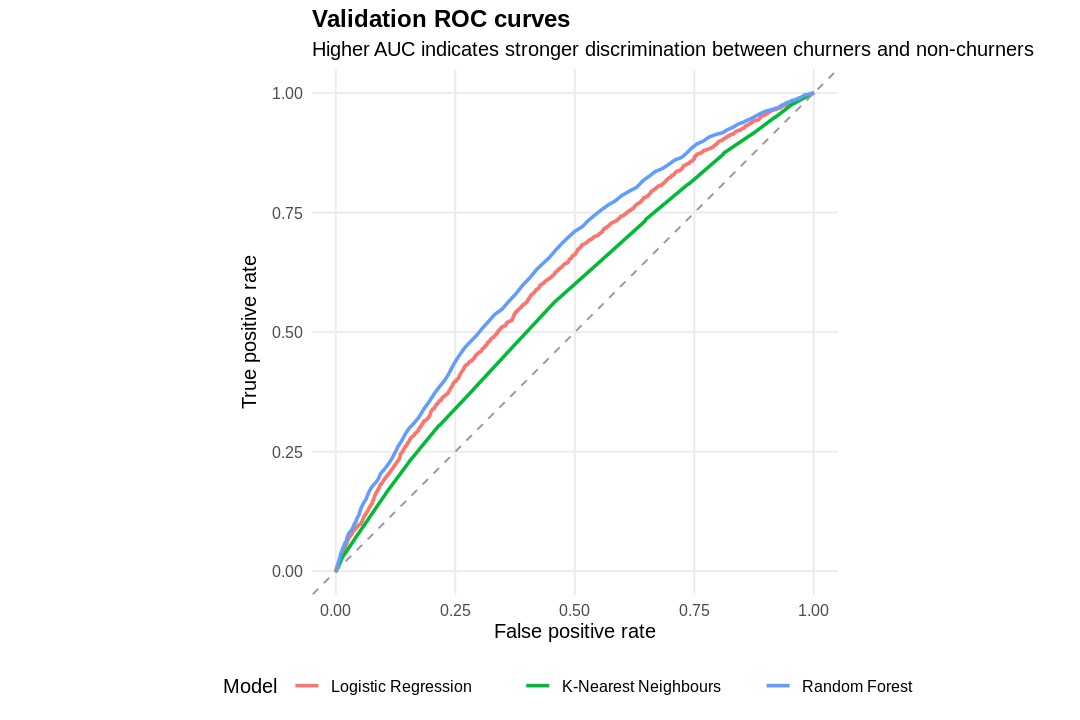

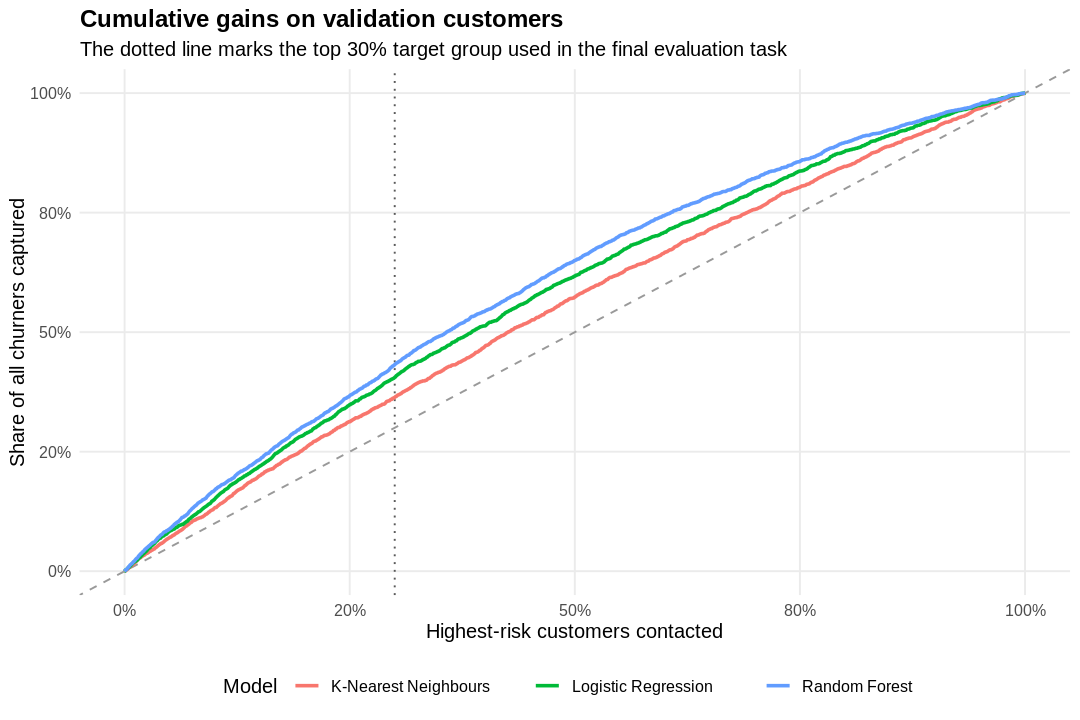

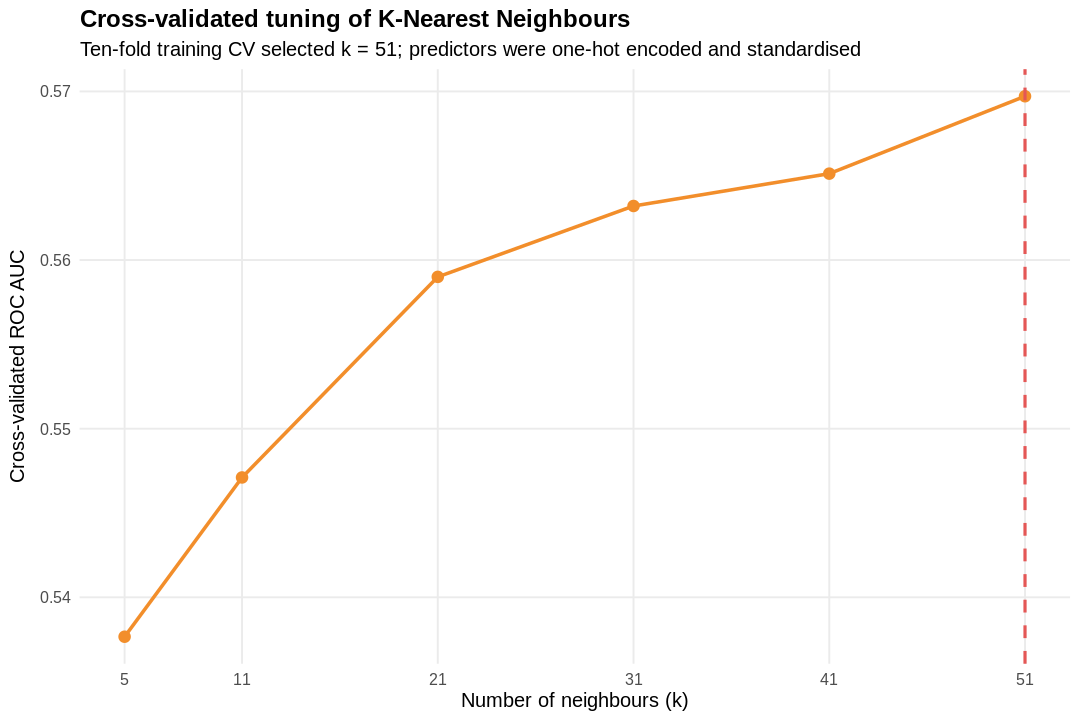

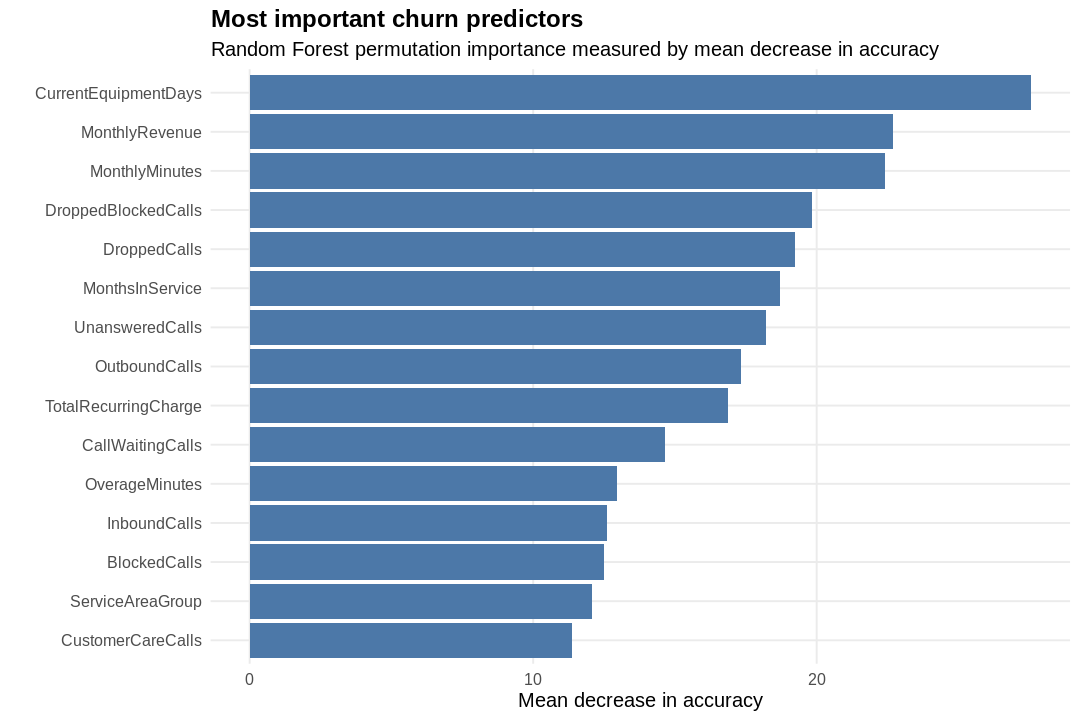

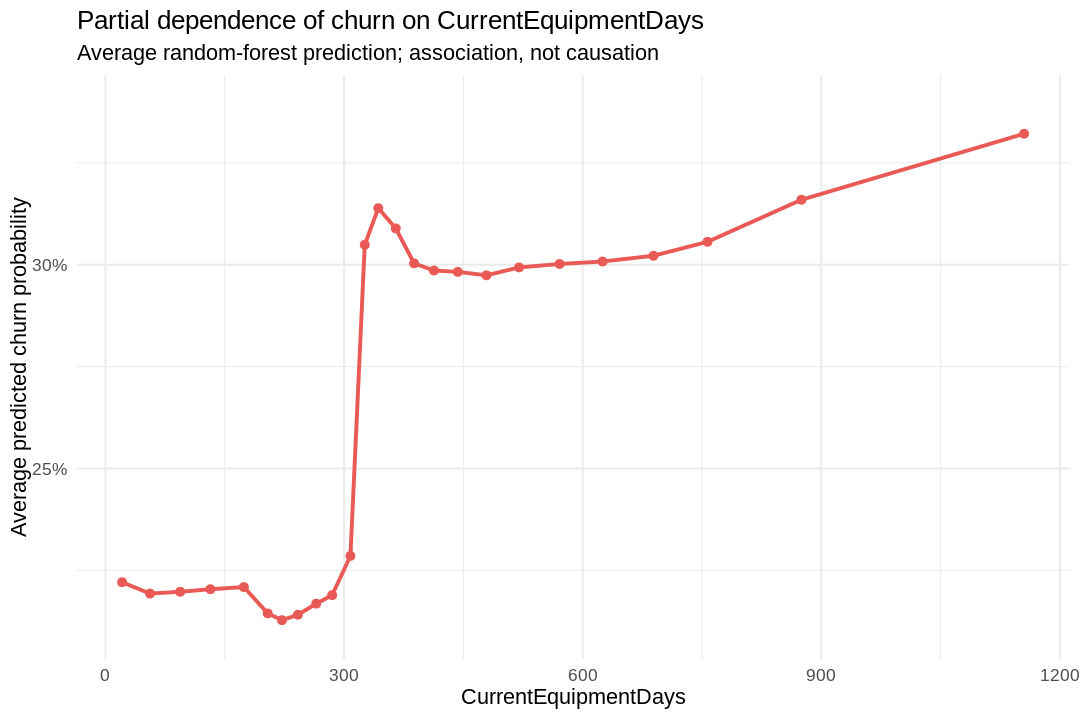

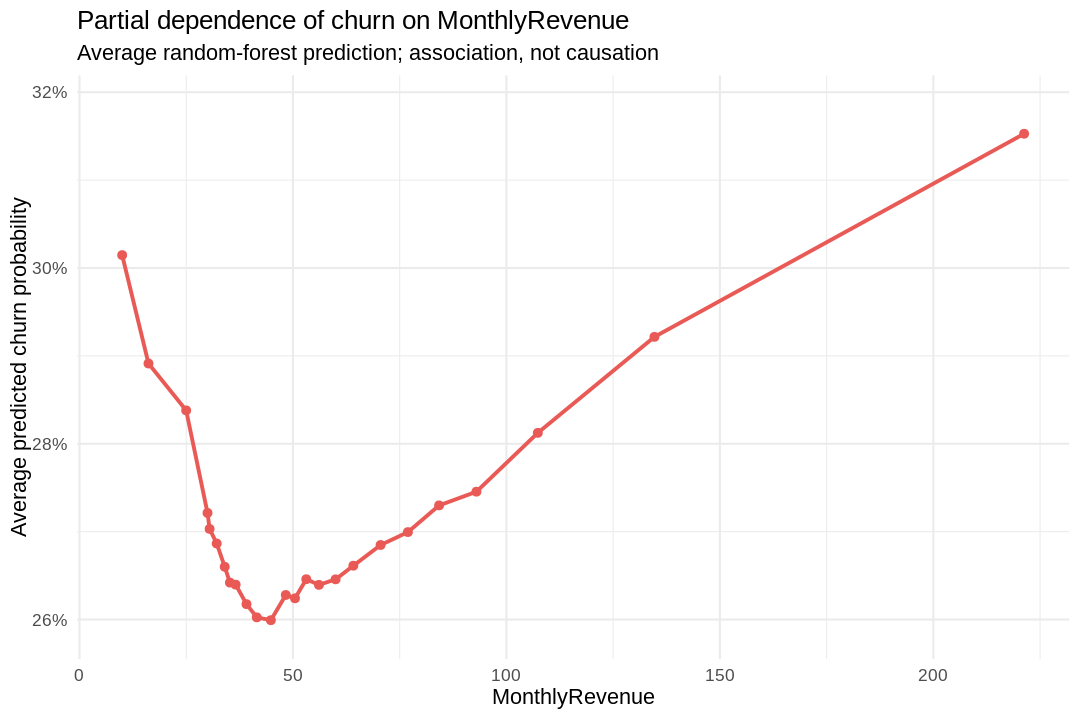


Most statistically significant logistic-regression terms:
                    Term   Estimate Odds_Ratio CI_Lower_95 CI_Upper_95
    CurrentEquipmentDays  0.0013130     1.0010      1.0010      1.0020
 MadeCallToRetentionTeam  0.6989000     2.0110      1.7110      2.3650
         MonthsInService -0.0209300     0.9793      0.9741      0.9845
      HandsetRefurbished  0.2706000     1.3110      1.1980      1.4340
            IncomeGroup6 -0.2771000     0.7580      0.6876      0.8357
            IncomeGroup4 -0.3131000     0.7311      0.6418      0.8329
          MonthlyMinutes -0.0002733     0.9997      0.9996      0.9998
            IncomeGroup3 -0.3428000     0.7098      0.6132      0.8215
    TotalRecurringCharge -0.0055190     0.9945      0.9921      0.9969
                Handsets  0.0668000     1.0690      1.0320      1.1070
            IncomeGroup5 -0.2368000     0.7892      0.6965      0.8942
          MonthlyRevenue  0.0038520     1.0040      1.0020      1.0060
            Income

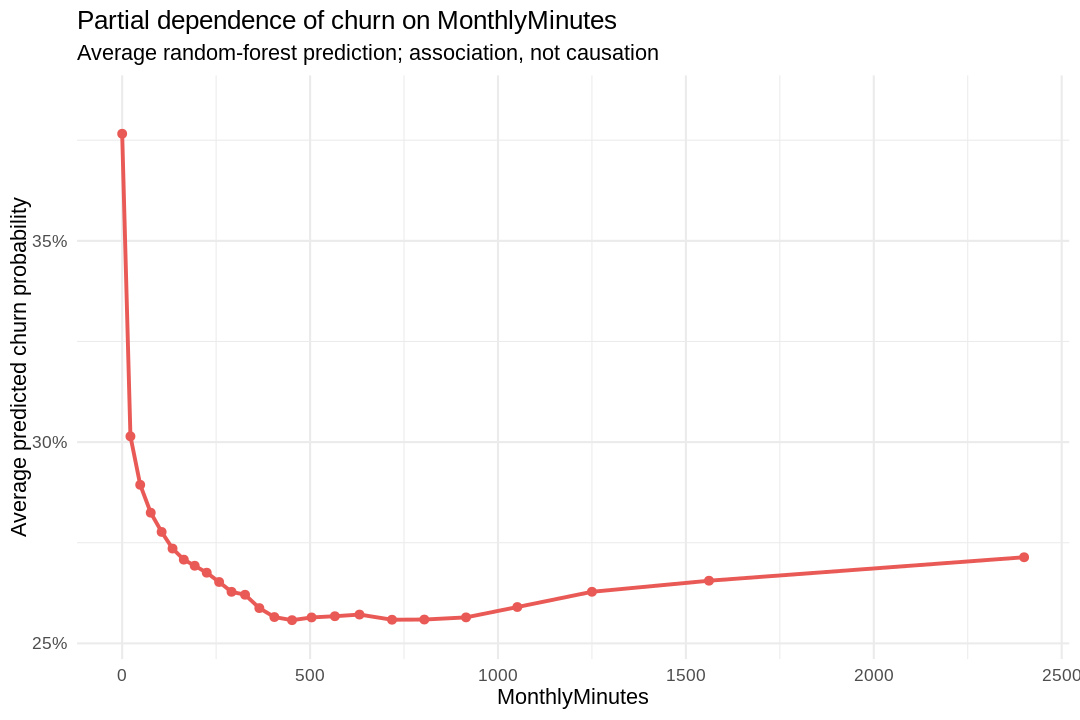

In [11]:
# =============================================================================
# COMM3501 A4 - 3. Predictive Modelling (R / Google Colab)
# =============================================================================
# Preferred workflow: run Step 1 (cleaning), Step 2 (EDA), then this script.
# This script uses the cleaned data frame `df` created in Step 1. If `df` is
# genuinely absent, it can still rebuild it directly from training_data.csv.
#
# AI use disclosure: OpenAI Codex was used for boilerplate generation,
# refactoring, and debugging. The student remains responsible for checking,
# interpreting, and reporting all results.


# 1. Packages and reproducibility -------------------------------------------
required_packages <- c(
  "dplyr", "ggplot2", "caret", "kknn",
  "randomForest", "pROC", "scales"
)

missing_packages <- required_packages[
  !vapply(required_packages, requireNamespace, logical(1), quietly = TRUE)
]

if (length(missing_packages) > 0) {
  install.packages(missing_packages, repos = "https://cloud.r-project.org")
}

suppressPackageStartupMessages({
  library(dplyr)
  library(ggplot2)
  library(caret)
  library(randomForest)
  library(pROC)
  library(scales)
})

set.seed(3501)
options(stringsAsFactors = FALSE, scipen = 999)
options(repr.plot.width = 9, repr.plot.height = 6, repr.plot.res = 120)


# 2. Use the cleaned in-memory data from Step 1 ------------------------------
cleaned_df_is_available <- exists(
  "df",
  envir = .GlobalEnv,
  inherits = FALSE
) && is.data.frame(get("df", envir = .GlobalEnv, inherits = FALSE)) &&
  all(
    c("CustomerID", "Churn") %in%
      names(get("df", envir = .GlobalEnv, inherits = FALSE))
  )

if (cleaned_df_is_available) {
  cat("Using the cleaned data frame `df` created in Step 1.\n")
} else {
  cat("`df` was not found; rebuilding it from training_data.csv.\n")

if (file.exists("training_data.csv")) {
  training_file <- "training_data.csv"
} else {
  stop("training_data.csv was not found. Please upload it and run the code again.")
}

raw <- read.csv(
  training_file,
  header = TRUE,
  stringsAsFactors = FALSE,
  check.names = FALSE,
  na.strings = c("", "NA")
)

names(raw) <- trimws(names(raw))

required_columns <- c(
  "CustomerID", "Churn", "MonthlyRevenue", "MonthlyMinutes",
  "TotalRecurringCharge", "OverageMinutes", "RoamingCalls", "ServiceArea",
  "Handsets", "CurrentEquipmentDays", "AgeHH1", "AgeHH2", "CreditRating",
  "IncomeGroup", "PrizmCode", "Occupation", "MaritalStatus"
)

missing_required_columns <- setdiff(required_columns, names(raw))
if (length(missing_required_columns) > 0) {
  stop(
    paste0(
      "training_data.csv is missing required columns: ",
      paste(missing_required_columns, collapse = ", ")
    )
  )
}

cat(
  "Loaded training_data.csv:", comma(nrow(raw)), "rows x",
  ncol(raw), "columns\n"
)

# Work on a copy so the imported raw data remains unchanged.
df <- raw

# Trim categorical text and change blank strings to NA.
text_columns <- names(df)[vapply(df, is.character, logical(1))]
for (variable_name in text_columns) {
  df[[variable_name]] <- trimws(df[[variable_name]])
  df[[variable_name]][df[[variable_name]] == ""] <- NA_character_
}

# Convert Yes/No target and predictors to 1/0.
binary_predictors <- c(
  "ChildrenInHH", "HandsetRefurbished", "HandsetWebCapable", "TruckOwner",
  "RVOwner", "BuysViaMailOrder", "RespondsToMailOffers", "OptOutMailings",
  "OwnsComputer", "HasCreditCard", "OwnsMotorcycle",
  "MadeCallToRetentionTeam"
)
binary_predictors <- intersect(binary_predictors, names(df))
yes_no_columns <- c("Churn", binary_predictors)

for (variable_name in yes_no_columns) {
  observed_values <- unique(na.omit(df[[variable_name]]))
  invalid_values <- setdiff(observed_values, c("Yes", "No"))

  if (length(invalid_values) > 0) {
    stop(
      paste0(
        "Unexpected value(s) in ", variable_name, ": ",
        paste(invalid_values, collapse = ", ")
      )
    )
  }

  df[[variable_name]] <- ifelse(
    is.na(df[[variable_name]]),
    NA_integer_,
    ifelse(df[[variable_name]] == "Yes", 1L, 0L)
  )
}

if (anyNA(df$CustomerID)) {
  stop("CustomerID contains missing values.")
}
if (anyNA(df$Churn)) {
  stop("Churn contains missing values and cannot be used for training.")
}

# Keep CustomerID and genuine categorical fields as text. Convert the other
# columns to numeric and stop if hidden text is discovered.
df$CustomerID <- as.character(df$CustomerID)
categorical_columns <- intersect(
  c("CustomerID", "ServiceArea", "PrizmCode", "Occupation", "MaritalStatus"),
  names(df)
)
numeric_columns <- setdiff(names(df), categorical_columns)

for (variable_name in numeric_columns) {
  originally_observed <- !is.na(df[[variable_name]])
  converted_values <- suppressWarnings(as.numeric(df[[variable_name]]))

  if (any(originally_observed & is.na(converted_values))) {
    stop(paste0("Hidden non-numeric value found in ", variable_name, "."))
  }

  df[[variable_name]] <- converted_values
}

# Treat zero household ages as unreported and preserve missingness indicators.
for (variable_name in intersect(c("AgeHH1", "AgeHH2"), names(df))) {
  flag_name <- paste0(variable_name, "_Missing")
  df[[flag_name]] <- as.integer(
    is.na(df[[variable_name]]) | df[[variable_name]] == 0
  )
  df[[variable_name]][df[[variable_name]] == 0] <- NA_real_
}

# Retain unusual billing values but flag them transparently.
df$MonthlyRevenue_Negative <- as.integer(
  !is.na(df$MonthlyRevenue) & df$MonthlyRevenue < 0
)
df$TotalRecurringCharge_Negative <- as.integer(
  !is.na(df$TotalRecurringCharge) & df$TotalRecurringCharge < 0
)

# Remove exact duplicate rows and require one row per customer.
df <- df[!duplicated(df), , drop = FALSE]
row.names(df) <- NULL

if (anyDuplicated(df$CustomerID) > 0) {
  stop("Duplicate CustomerIDs remain after removing exact duplicate rows.")
}

stopifnot(all(df$Churn %in% c(0, 1)))

cat(
  "Cleaned in memory:", comma(nrow(df)), "customers x",
  ncol(df), "columns\n"
)

}

model_data <- df
model_data$CustomerID <- as.character(model_data$CustomerID)
model_data$Churn <- factor(
  model_data$Churn,
  levels = c(0, 1),
  labels = c("Stayed", "Churned")
)

cat(
  "Modelling data:", comma(nrow(model_data)), "customers x",
  ncol(model_data), "columns\n"
)
print(prop.table(table(model_data$Churn)))


# 3. Stratified training-validation split ----------------------------------
# The validation set is untouched during model fitting. A 70/30 split also
# mirrors the assignment's final task of ranking the top 3,000 of 10,000.
set.seed(3501)
training_index <- createDataPartition(
  model_data$Churn,
  p = 0.70,
  list = FALSE
)

training_raw <- model_data[training_index, , drop = FALSE]
validation_raw <- model_data[-training_index, , drop = FALSE]

cat("\nTraining customers:", comma(nrow(training_raw)), "\n")
cat("Validation customers:", comma(nrow(validation_raw)), "\n")
cat("Training churn rate:", percent(mean(training_raw$Churn == "Churned"), 0.1), "\n")
cat("Validation churn rate:", percent(mean(validation_raw$Churn == "Churned"), 0.1), "\n")


# 4. Leakage-safe preprocessing --------------------------------------------
statistical_mode <- function(x) {
  observed <- x[!is.na(x)]
  if (length(observed) == 0) return(NA_character_)
  names(sort(table(observed), decreasing = TRUE))[1]
}

# ServiceArea has hundreds of exact codes. The first three characters identify
# a broader service region. The 30 most common TRAINING regions are retained;
# the rest are grouped as Other so tree models do not overfit sparse levels.
make_service_prefix <- function(x) {
  x <- trimws(as.character(x))
  ifelse(is.na(x) | x == "", "Missing", substr(x, 1, 3))
}

training_raw$ServiceAreaPrefix <- make_service_prefix(training_raw$ServiceArea)
validation_raw$ServiceAreaPrefix <- make_service_prefix(validation_raw$ServiceArea)

service_counts <- sort(table(training_raw$ServiceAreaPrefix), decreasing = TRUE)
retained_service_prefixes <- head(names(service_counts), 30)

collapse_service_area <- function(x, retained_levels) {
  ifelse(x %in% retained_levels, x, "Other")
}

training_raw$ServiceAreaGroup <- collapse_service_area(
  training_raw$ServiceAreaPrefix,
  retained_service_prefixes
)
validation_raw$ServiceAreaGroup <- collapse_service_area(
  validation_raw$ServiceAreaPrefix,
  retained_service_prefixes
)

training_raw$ServiceArea <- NULL
training_raw$ServiceAreaPrefix <- NULL
validation_raw$ServiceArea <- NULL
validation_raw$ServiceAreaPrefix <- NULL

# These assignment variables are categorical even if some were read as numbers.
factor_predictors <- intersect(
  c(
    "ServiceAreaGroup", "CreditRating", "IncomeGroup", "PrizmCode",
    "Occupation", "MaritalStatus"
  ),
  names(training_raw)
)

factor_levels <- list()
factor_modes <- list()

for (variable_name in factor_predictors) {
  train_values <- as.character(training_raw[[variable_name]])
  validation_values <- as.character(validation_raw[[variable_name]])

  train_values[is.na(train_values) | train_values == ""] <- "Missing"
  validation_values[is.na(validation_values) | validation_values == ""] <- "Missing"

  factor_modes[[variable_name]] <- statistical_mode(train_values)
  factor_levels[[variable_name]] <- sort(unique(train_values))

  # Map any future/unseen validation level to the most common training level.
  validation_values[!validation_values %in% factor_levels[[variable_name]]] <-
    factor_modes[[variable_name]]

  training_raw[[variable_name]] <- factor(
    train_values,
    levels = factor_levels[[variable_name]]
  )
  validation_raw[[variable_name]] <- factor(
    validation_values,
    levels = factor_levels[[variable_name]]
  )
}

# Compute numeric medians from training only. Step 1 already created the useful
# AgeHH1/AgeHH2 missingness indicators. Several other variables share exactly
# the same missing rows, so creating one flag per variable would produce exact
# duplicate columns and a rank-deficient logistic regression.
excluded_columns <- c("CustomerID", "Churn", factor_predictors)
numeric_predictors <- setdiff(names(training_raw), excluded_columns)
numeric_predictors <- numeric_predictors[
  vapply(training_raw[numeric_predictors], is.numeric, logical(1))
]

numeric_medians <- list()
created_missing_flags <- character(0)

for (variable_name in numeric_predictors) {
  median_value <- median(training_raw[[variable_name]], na.rm = TRUE)
  if (!is.finite(median_value)) median_value <- 0
  numeric_medians[[variable_name]] <- median_value

  training_raw[[variable_name]][is.na(training_raw[[variable_name]])] <- median_value
  validation_raw[[variable_name]][is.na(validation_raw[[variable_name]])] <- median_value
}

training_prepared <- training_raw
validation_prepared <- validation_raw

# CustomerID is retained for ranking customers, but never enters a model.
training_model <- training_prepared %>% select(-CustomerID)
validation_model <- validation_prepared %>% select(-CustomerID)

if (anyNA(training_model) || anyNA(validation_model)) {
  stop("Missing values remain after preprocessing.")
}

if (!identical(names(training_model), names(validation_model))) {
  stop("Training and validation model columns do not match.")
}

cat("\nPrepared model predictors:", ncol(training_model) - 1, "\n")
cat("Service-area groups:", nlevels(training_model$ServiceAreaGroup), "\n")
cat("Additional missingness flags created during modelling:", length(created_missing_flags), "\n")


# 5. Model 1 - Logistic Regression baseline --------------------------------
# Use a deliberately compact, interpretable baseline. The full 46-predictor
# specification contained redundant/very sparse terms and produced a
# rank-deficient fit. Predictors were retained for EDA evidence, business
# relevance, and interpretable coverage of usage, billing, tenure, equipment,
# demographics, and retention contact. Model comparison remains fair because
# every model uses exactly the same training and validation customers.
logistic_predictors <- intersect(
  c(
    "CurrentEquipmentDays", "MonthlyRevenue", "MonthlyMinutes",
    "TotalRecurringCharge", "OverageMinutes", "RoamingCalls",
    "DroppedCalls", "BlockedCalls", "UnansweredCalls",
    "CustomerCareCalls", "MonthsInService", "Handsets",
    "AgeHH1", "AgeHH2", "ChildrenInHH", "HandsetRefurbished",
    "HandsetWebCapable", "MadeCallToRetentionTeam",
    "CreditRating", "IncomeGroup"
  ),
  names(training_model)
)

logistic_training <- training_model %>%
  select(Churn, all_of(logistic_predictors))

logistic_validation <- validation_model %>%
  select(Churn, all_of(logistic_predictors))

logistic_model <- glm(
  Churn ~ .,
  data = logistic_training,
  family = binomial(link = "logit")
)

if (logistic_model$rank < length(coef(logistic_model))) {
  stop(
    "The reduced logistic baseline is still rank deficient. ",
    "Inspect the selected logistic predictors before continuing."
  )
}

logistic_probability <- predict(
  logistic_model,
  newdata = logistic_validation,
  type = "response"
)

if (anyNA(logistic_probability)) {
  stop("Logistic regression produced missing validation probabilities.")
}


# 6. Model 2 - Cross-validated K-Nearest Neighbours -------------------------
# KNN is distance based, so it is more sensitive than the other models to
# irrelevant, duplicated, high-cardinality, and differently scaled features.
# The following compact predictor set was chosen before validation scoring
# using EDA patterns, business relevance, and avoidance of redundant measures.
knn_predictors <- intersect(
  c(
    "CurrentEquipmentDays", "MonthlyRevenue", "MonthlyMinutes",
    "TotalRecurringCharge", "OverageMinutes", "RoamingCalls",
    "DroppedBlockedCalls", "UnansweredCalls", "CustomerCareCalls",
    "OutboundCalls", "InboundCalls", "CallWaitingCalls",
    "MonthsInService", "Handsets", "AgeHH1", "AgeHH2",
    "AgeHH1_Missing", "AgeHH2_Missing",
    "ChildrenInHH", "HandsetRefurbished", "HandsetWebCapable",
    "MadeCallToRetentionTeam", "CreditRating", "IncomeGroup"
  ),
  names(training_model)
)

knn_training_source <- training_model %>%
  select(all_of(knn_predictors))

knn_validation_source <- validation_model %>%
  select(all_of(knn_predictors))

# Estimate one-hot encoding from the training partition only. fullRank = TRUE
# avoids one redundant dummy column for each factor.
knn_dummy_encoder <- dummyVars(
  ~ .,
  data = knn_training_source,
  fullRank = TRUE
)

knn_training_matrix <- predict(
  knn_dummy_encoder,
  newdata = knn_training_source
) %>%
  as.data.frame()

knn_validation_matrix <- predict(
  knn_dummy_encoder,
  newdata = knn_validation_source
) %>%
  as.data.frame()

# Remove zero-variance and near-zero-variance encoded columns, which carry
# little distance information and can destabilise a nearest-neighbour model.
knn_nzv <- nearZeroVar(knn_training_matrix, saveMetrics = TRUE)
knn_model_columns <- rownames(knn_nzv)[!knn_nzv$nzv]

knn_training_matrix <- knn_training_matrix[
  , knn_model_columns, drop = FALSE
]
knn_validation_matrix <- knn_validation_matrix[
  , knn_model_columns, drop = FALSE
]

if (anyNA(knn_training_matrix) || anyNA(knn_validation_matrix)) {
  stop("Missing values remain in the KNN feature matrices.")
}

knn_control <- trainControl(
  method = "cv",
  number = 10,
  classProbs = TRUE,
  summaryFunction = twoClassSummary,
  savePredictions = "final"
)

# Odd values reduce voting ties. The grid covers local through smoother
# neighbourhoods without using the independent validation partition.
knn_grid <- data.frame(k = c(5, 11, 21, 31, 41, 51))

set.seed(3501)
knn_model <- train(
  x = knn_training_matrix,
  y = training_model$Churn,
  method = "knn",
  metric = "ROC",
  trControl = knn_control,
  tuneGrid = knn_grid,
  preProcess = c("center", "scale")
)

knn_probability <- predict(
  knn_model,
  newdata = knn_validation_matrix,
  type = "prob"
)[, "Churned"]

if (anyNA(knn_probability)) {
  stop("KNN produced missing validation probabilities.")
}

knn_tuning_results <- knn_model$results %>%
  select(k, ROC, Sens, Spec) %>%
  arrange(k)

cat("\nKNN tuning results:\n")
print(knn_tuning_results)
cat("Selected k:", knn_model$bestTune$k, "\n")


# 7. Model 3 - Tuned Random Forest -----------------------------------------
# Unlike distance-based KNN and coefficient-based logistic regression, Random
# Forest can accommodate a broad predictor set, non-linearities, and feature
# interactions. It therefore uses all cleaned predictors after CustomerID is
# excluded and high-cardinality ServiceArea is collapsed to broader regions.
# Candidate mtry values are compared using training out-of-bag error. The
# independent validation set is not used to tune the forest.
predictor_count <- ncol(training_model) - 1
default_mtry <- sqrt(predictor_count)
mtry_candidates <- unique(pmax(
  2,
  pmin(
    predictor_count,
    round(c(default_mtry / 2, default_mtry, default_mtry * 2))
  )
))

rf_tuning_results <- data.frame(
  mtry = mtry_candidates,
  OOB_Error = NA_real_
)

for (i in seq_along(mtry_candidates)) {
  set.seed(3501 + i)
  tuning_forest <- randomForest(
    Churn ~ .,
    data = training_model,
    ntree = 100,
    mtry = mtry_candidates[i],
    nodesize = 10,
    importance = FALSE
  )

  rf_tuning_results$OOB_Error[i] <- tail(
    tuning_forest$err.rate[, "OOB"],
    1
  )
}

best_mtry <- rf_tuning_results$mtry[which.min(rf_tuning_results$OOB_Error)]

set.seed(3501)
random_forest_model <- randomForest(
  Churn ~ .,
  data = training_model,
  ntree = 300,
  mtry = best_mtry,
  nodesize = 10,
  importance = TRUE,
  keep.forest = TRUE
)

random_forest_probability <- predict(
  random_forest_model,
  newdata = validation_model,
  type = "prob"
)[, "Churned"]

cat("\nRandom Forest tuning results:\n")
print(rf_tuning_results)
cat("Selected mtry:", best_mtry, "\n")
cat("Final number of trees: 300\n")


# 8. Validation metrics -----------------------------------------------------
# AUC and top-30% lift assess probability ranking. Log loss and Brier score
# assess probability quality. Threshold-dependent metrics use 0.50 here; the
# assignment's profit-maximising threshold is determined in the next stage.
evaluate_probabilities <- function(actual, probability, model_name) {
  probability <- pmin(pmax(probability, 0.000001), 0.999999)
  predicted_class <- factor(
    ifelse(probability >= 0.50, "Churned", "Stayed"),
    levels = c("Stayed", "Churned")
  )

  confusion <- confusionMatrix(
    predicted_class,
    actual,
    positive = "Churned"
  )

  roc_object <- roc(
    response = actual,
    predictor = probability,
    levels = c("Stayed", "Churned"),
    direction = "<",
    quiet = TRUE
  )

  actual_numeric <- as.integer(actual == "Churned")
  top_n <- ceiling(0.30 * length(probability))
  top_rows <- order(probability, decreasing = TRUE)[seq_len(top_n)]
  top_churn_rate <- mean(actual_numeric[top_rows])
  overall_churn_rate <- mean(actual_numeric)

  data.frame(
    Model = model_name,
    AUC = as.numeric(auc(roc_object)),
    LogLoss = -mean(
      actual_numeric * log(probability) +
        (1 - actual_numeric) * log(1 - probability)
    ),
    BrierScore = mean((actual_numeric - probability)^2),
    Accuracy_050 = unname(confusion$overall["Accuracy"]),
    Sensitivity_050 = unname(confusion$byClass["Sensitivity"]),
    Specificity_050 = unname(confusion$byClass["Specificity"]),
    Precision_050 = unname(confusion$byClass["Pos Pred Value"]),
    F1_050 = unname(confusion$byClass["F1"]),
    Top30_Precision = top_churn_rate,
    Top30_Recall = sum(actual_numeric[top_rows]) / sum(actual_numeric),
    Top30_Lift = top_churn_rate / overall_churn_rate,
    stringsAsFactors = FALSE
  )
}

model_performance <- bind_rows(
  evaluate_probabilities(
    validation_model$Churn,
    logistic_probability,
    "Logistic Regression"
  ),
  evaluate_probabilities(
    validation_model$Churn,
    knn_probability,
    "K-Nearest Neighbours"
  ),
  evaluate_probabilities(
    validation_model$Churn,
    random_forest_probability,
    "Random Forest"
  )
) %>%
  arrange(desc(AUC), desc(Top30_Lift), LogLoss)

cat("\nValidation performance:\n")
print(as.data.frame(model_performance), digits = 4, row.names = FALSE)

write.csv(
  model_performance,
  "predictive_model_performance.csv",
  row.names = FALSE
)

# Select the model with the strongest validation AUC, using top-30% lift and
# log loss as tie-breakers. This keeps model selection evidence based.
selected_model_name <- model_performance$Model[1]

selected_model <- switch(
  selected_model_name,
  "Logistic Regression" = logistic_model,
  "K-Nearest Neighbours" = knn_model,
  "Random Forest" = random_forest_model
)

selected_validation_probability <- switch(
  selected_model_name,
  "Logistic Regression" = logistic_probability,
  "K-Nearest Neighbours" = knn_probability,
  "Random Forest" = random_forest_probability
)

cat("\nSelected model based on validation ranking:", selected_model_name, "\n")


# 9. Separate model-comparison figures -------------------------------------
roc_objects <- list(
  "Logistic Regression" = roc(
    validation_model$Churn, logistic_probability,
    levels = c("Stayed", "Churned"), direction = "<", quiet = TRUE
  ),
  "K-Nearest Neighbours" = roc(
    validation_model$Churn, knn_probability,
    levels = c("Stayed", "Churned"), direction = "<", quiet = TRUE
  ),
  "Random Forest" = roc(
    validation_model$Churn, random_forest_probability,
    levels = c("Stayed", "Churned"), direction = "<", quiet = TRUE
  )
)

plot_roc <- ggroc(roc_objects, legacy.axes = TRUE, linewidth = 1) +
  geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "grey60") +
  coord_equal() +
  labs(
    title = "Validation ROC curves",
    subtitle = "Higher AUC indicates stronger discrimination between churners and non-churners",
    x = "False positive rate",
    y = "True positive rate",
    color = "Model"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold"),
    legend.position = "bottom",
    panel.grid.minor = element_blank()
  )

print(plot_roc)
ggsave(
  "predictive_01_roc_comparison.png",
  plot_roc,
  width = 8,
  height = 6,
  dpi = 300
)

make_gains_data <- function(actual, probability, model_name) {
  ordered <- data.frame(
    Actual = as.integer(actual == "Churned"),
    Probability = probability
  ) %>%
    arrange(desc(Probability)) %>%
    mutate(
      Population_Share = row_number() / n(),
      Churn_Captured = cumsum(Actual) / sum(Actual)
    ) %>%
    select(Population_Share, Churn_Captured)

  bind_rows(
    data.frame(Population_Share = 0, Churn_Captured = 0),
    ordered
  ) %>%
    mutate(Model = model_name)
}

gains_data <- bind_rows(
  make_gains_data(validation_model$Churn, logistic_probability, "Logistic Regression"),
  make_gains_data(validation_model$Churn, knn_probability, "K-Nearest Neighbours"),
  make_gains_data(validation_model$Churn, random_forest_probability, "Random Forest")
)

plot_gains <- ggplot(
  gains_data,
  aes(x = Population_Share, y = Churn_Captured, color = Model)
) +
  geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "grey60") +
  geom_vline(xintercept = 0.30, linetype = "dotted", color = "grey35") +
  geom_line(linewidth = 1) +
  scale_x_continuous(labels = percent_format(accuracy = 10)) +
  scale_y_continuous(labels = percent_format(accuracy = 10)) +
  labs(
    title = "Cumulative gains on validation customers",
    subtitle = "The dotted line marks the top 30% target group used in the final evaluation task",
    x = "Highest-risk customers contacted",
    y = "Share of all churners captured",
    color = "Model"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold"),
    legend.position = "bottom",
    panel.grid.minor = element_blank()
  )

print(plot_gains)
ggsave(
  "predictive_02_cumulative_gains.png",
  plot_gains,
  width = 8,
  height = 6,
  dpi = 300
)


# 10. KNN tuning visualisation ---------------------------------------------
write.csv(
  knn_tuning_results,
  "predictive_knn_tuning_results.csv",
  row.names = FALSE
)

plot_knn_tuning <- ggplot(
  knn_tuning_results,
  aes(x = k, y = ROC)
) +
  geom_line(colour = "#F28E2B", linewidth = 1) +
  geom_point(colour = "#F28E2B", size = 2.8) +
  geom_vline(
    xintercept = knn_model$bestTune$k,
    colour = "#E45756",
    linetype = "dashed",
    linewidth = 0.9
  ) +
  scale_x_continuous(breaks = knn_grid$k) +
  labs(
    title = "Cross-validated tuning of K-Nearest Neighbours",
    subtitle = paste0(
      "Ten-fold training CV selected k = ", knn_model$bestTune$k,
      "; predictors were one-hot encoded and standardised"
    ),
    x = "Number of neighbours (k)",
    y = "Cross-validated ROC AUC"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold"),
    panel.grid.minor = element_blank()
  )

print(plot_knn_tuning)
ggsave(
  "predictive_03_knn_tuning.png",
  plot_knn_tuning,
  width = 8,
  height = 5.3,
  dpi = 300
)


# 11. Random Forest feature importance -------------------------------------
rf_importance_matrix <- importance(random_forest_model, type = 1)
rf_importance <- data.frame(
  Feature = rownames(rf_importance_matrix),
  Importance = rf_importance_matrix[, 1],
  stringsAsFactors = FALSE
) %>%
  arrange(desc(Importance))

write.csv(
  rf_importance,
  "predictive_random_forest_importance.csv",
  row.names = FALSE
)

plot_importance <- rf_importance %>%
  slice_head(n = 15) %>%
  ggplot(aes(x = reorder(Feature, Importance), y = Importance)) +
  geom_col(fill = "#4C78A8") +
  coord_flip() +
  labs(
    title = "Most important churn predictors",
    subtitle = "Random Forest permutation importance measured by mean decrease in accuracy",
    x = NULL,
    y = "Mean decrease in accuracy"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold"),
    panel.grid.minor = element_blank()
  )

print(plot_importance)
ggsave(
  "predictive_04_random_forest_importance.png",
  plot_importance,
  width = 8.5,
  height = 6,
  dpi = 300
)


# 12. Separate Random Forest probability PDPs -------------------------------
# For each grid value, replace one feature for a fixed sample of customers and
# average their predicted churn probabilities. This produces a genuine 0-1
# probability-scale PDP. It also avoids randomForest::partialPlot(), whose
# classification output is a centred logit rather than a probability.
available_numeric_features <- names(training_model)[
  vapply(training_model, is.numeric, logical(1))
]
available_numeric_features <- setdiff(available_numeric_features, "Churn")

top_numeric_features <- rf_importance %>%
  filter(Feature %in% available_numeric_features) %>%
  slice_head(n = 3) %>%
  pull(Feature)

set.seed(3501)
pdp_sample_rows <- sample(
  seq_len(nrow(training_model)),
  size = min(5000, nrow(training_model)),
  replace = FALSE
)
pdp_reference_data <- training_model[pdp_sample_rows, , drop = FALSE]
all_pdp_data <- list()

for (i in seq_along(top_numeric_features)) {
  feature_name <- top_numeric_features[i]
  file_name <- paste0(
    "predictive_05", letters[i], "_pdp_",
    gsub("[^A-Za-z0-9]+", "_", feature_name), ".png"
  )

  feature_grid <- unique(as.numeric(quantile(
    training_model[[feature_name]],
    probs = seq(0.01, 0.99, length.out = 25),
    na.rm = TRUE,
    names = FALSE
  )))

  pdp_probability <- vapply(
    feature_grid,
    function(grid_value) {
      scenario_data <- pdp_reference_data
      scenario_data[[feature_name]] <- grid_value
      mean(
        predict(
          random_forest_model,
          newdata = scenario_data,
          type = "prob"
        )[, "Churned"]
      )
    },
    numeric(1)
  )

  pdp_data <- data.frame(
    Feature = feature_name,
    Feature_Value = feature_grid,
    Average_Churn_Probability = pdp_probability,
    stringsAsFactors = FALSE
  )
  all_pdp_data[[i]] <- pdp_data

  pdp_plot <- ggplot(
    pdp_data,
    aes(x = Feature_Value, y = Average_Churn_Probability)
  ) +
    geom_line(colour = "#E95A56", linewidth = 1.1) +
    geom_point(colour = "#E95A56", size = 2) +
    scale_y_continuous(
      labels = scales::percent_format(accuracy = 1),
      expand = expansion(mult = c(0.08, 0.12))
    ) +
    labs(
      title = paste("Partial dependence of churn on", feature_name),
      subtitle = "Average random-forest prediction; association, not causation",
      x = feature_name,
      y = "Average predicted churn probability"
    ) +
    theme_minimal(base_size = 13)

  print(pdp_plot)
  ggsave(file_name, pdp_plot, width = 9, height = 6, dpi = 200)
}

if (length(all_pdp_data) > 0) {
  write.csv(
    bind_rows(all_pdp_data),
    "predictive_random_forest_pdp_values.csv",
    row.names = FALSE
  )
}


# 13. Logistic Regression odds ratios --------------------------------------
logistic_coefficients <- as.data.frame(coef(summary(logistic_model)))
logistic_coefficients$Term <- rownames(logistic_coefficients)
rownames(logistic_coefficients) <- NULL

logistic_odds_ratios <- logistic_coefficients %>%
  filter(Term != "(Intercept)", !is.na(Estimate)) %>%
  transmute(
    Term = Term,
    Estimate = Estimate,
    Odds_Ratio = exp(Estimate),
    CI_Lower_95 = exp(Estimate - 1.96 * `Std. Error`),
    CI_Upper_95 = exp(Estimate + 1.96 * `Std. Error`),
    P_Value = `Pr(>|z|)`
  ) %>%
  arrange(P_Value)

write.csv(
  logistic_odds_ratios,
  "predictive_logistic_odds_ratios.csv",
  row.names = FALSE
)

cat("\nMost statistically significant logistic-regression terms:\n")
logistic_display <- head(logistic_odds_ratios, 15) %>%
  mutate(
    across(c(Estimate, Odds_Ratio, CI_Lower_95, CI_Upper_95), ~ signif(.x, 4)),
    P_Value = format.pval(P_Value, digits = 3, eps = 0.0000000000000002)
  )
print(as.data.frame(logistic_display), row.names = FALSE)


# 14. Save validation predictions and reusable model objects ----------------
validation_predictions <- data.frame(
  CustomerID = validation_prepared$CustomerID,
  Actual_Churn = validation_model$Churn,
  Logistic_Probability = logistic_probability,
  KNN_Probability = knn_probability,
  Random_Forest_Probability = random_forest_probability,
  Selected_Model_Probability = selected_validation_probability,
  stringsAsFactors = FALSE
) %>%
  arrange(desc(Selected_Model_Probability)) %>%
  mutate(
    Risk_Rank = row_number(),
    Top_30_Percent = Risk_Rank <= ceiling(0.30 * n())
  )

write.csv(
  validation_predictions,
  "predictive_validation_predictions.csv",
  row.names = FALSE
)

preprocessing_information <- list(
  retained_service_prefixes = retained_service_prefixes,
  factor_predictors = factor_predictors,
  factor_levels = factor_levels,
  factor_modes = factor_modes,
  numeric_predictors = numeric_predictors,
  numeric_medians = numeric_medians,
  created_missing_flags = created_missing_flags,
  model_columns = names(training_model),
  logistic_predictors = logistic_predictors,
  knn_predictors = knn_predictors,
  knn_dummy_encoder = knn_dummy_encoder,
  knn_model_columns = knn_model_columns
)

saveRDS(logistic_model, "predictive_logistic_model.rds")
saveRDS(knn_model, "predictive_knn_model.rds")
saveRDS(random_forest_model, "predictive_random_forest_model.rds")
saveRDS(selected_model, "predictive_selected_model.rds")
saveRDS(preprocessing_information, "predictive_preprocessing_information.rds")

cat(
  "\nPredictive modelling is complete.\n",
  "Selected model: ", selected_model_name, "\n",
  "Use AUC and top-30% lift for ranking performance; use the next assignment\n",
  "stage to determine the profit-maximising probability threshold.\n",
  sep = ""
)

stochastic modelling

Using the cleaned training data `df` and the Random Forest selected in Step 3.
Loaded eval_data.csv: 10,000 customers x 43 columns
Final Random Forest refitted on 30,000 customers with mtry = 3 and 300 trees.


Warning message:
“2 top-3,000 customers have non-positive annual revenue. The assignment profit formula has been applied without alteration; discuss this data limitation in the report.”



Stochastic modelling summary:
Highest-risk customers analysed: 3,000 
Final probability threshold: 35.7% 
Discount offers within top 3,000: 2,386 
Monte Carlo runs: 10,000 
Expected churns under rule: 314.3 
95th-percentile total churns: 340 
Expected total profit under rule: $193,608 
5th-percentile total profit: $190,774 
Expected profit uplift versus no offers: $12,790 


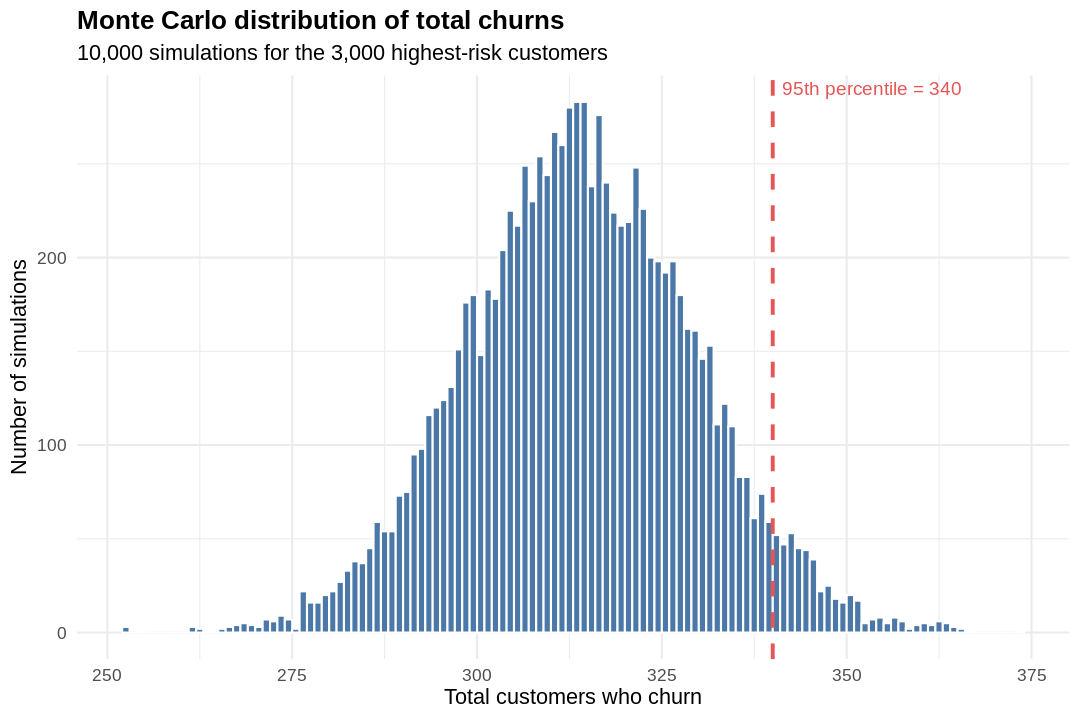

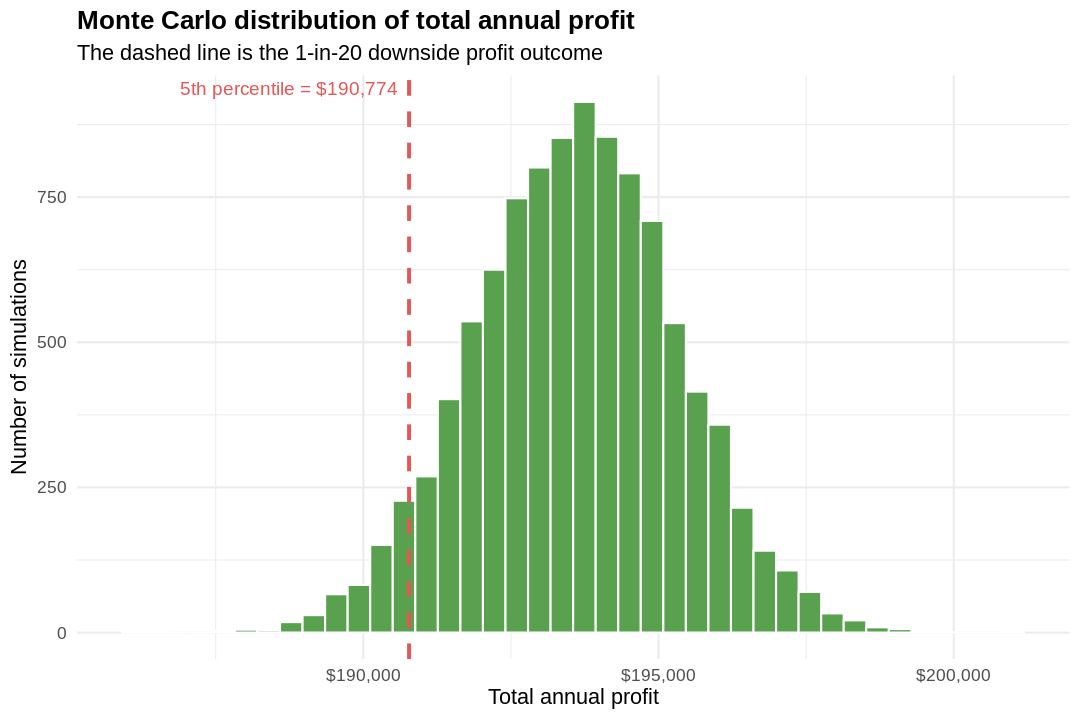

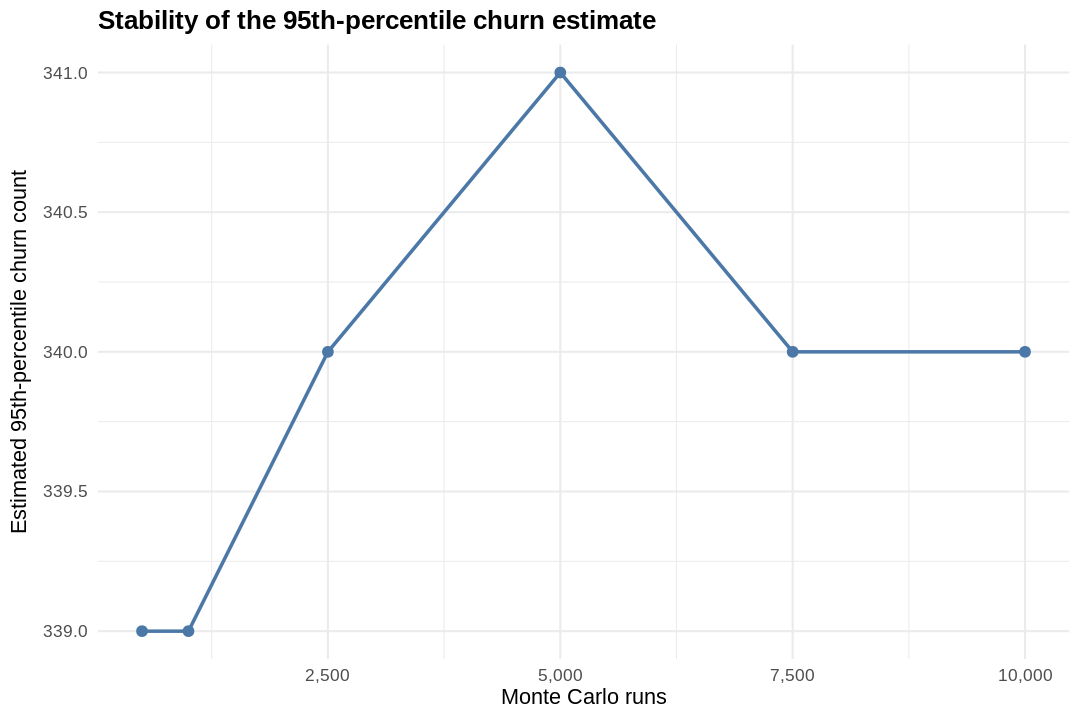


Stochastic modelling is complete. The required tail-risk metrics, customer-level actions, Monte Carlo results, stability checks, and separate PNG charts have been saved.


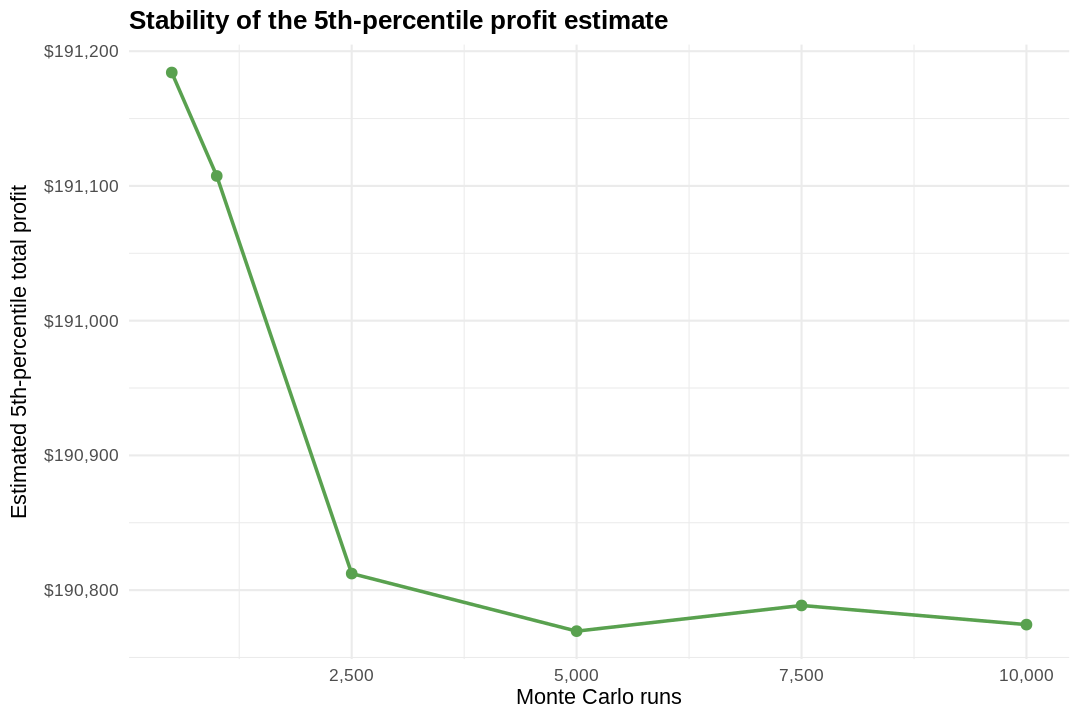

In [12]:
# =============================================================================
# COMM3501 A4 - 4. Stochastic Modelling (R / Google Colab)
# =============================================================================
# Run Steps 1 and 3 before this section, then upload eval_data.csv.
#
# This section:
#   1. cleans and prepares eval_data.csv in the same way as the training data;
#   2. refits the selected Random Forest on all 30,000 training customers;
#   3. identifies the 3,000 customers with the highest predicted churn risk;
#   4. applies the profit-based 5% discount threshold; and
#   5. runs a 10,000-trial Monte Carlo simulation of churns and annual profit.
#
# AI use disclosure: OpenAI Codex was used for boilerplate generation,
# refactoring, and debugging. The student remains responsible for checking,
# interpreting, and reporting all results.


# 1. Packages, reproducibility, and prerequisites --------------------------
required_packages <- c("dplyr", "ggplot2", "randomForest", "scales")

missing_packages <- required_packages[
  !vapply(required_packages, requireNamespace, logical(1), quietly = TRUE)
]

if (length(missing_packages) > 0) {
  install.packages(missing_packages, repos = "https://cloud.r-project.org")
}

suppressPackageStartupMessages({
  library(dplyr)
  library(ggplot2)
  library(randomForest)
  library(scales)
})

set.seed(3501)
options(stringsAsFactors = FALSE, scipen = 999)
options(repr.plot.width = 9, repr.plot.height = 6, repr.plot.res = 120)

if (!exists("df", envir = .GlobalEnv, inherits = FALSE) ||
    !is.data.frame(get("df", envir = .GlobalEnv, inherits = FALSE))) {
  stop("The cleaned training data frame `df` was not found. Run Step 1 first.")
}

if (!exists("selected_model_name", envir = .GlobalEnv, inherits = FALSE)) {
  stop("The selected model was not found. Run Step 3 first.")
}

if (selected_model_name != "Random Forest") {
  stop(
    paste0(
      "Step 3 selected ", selected_model_name,
      ", but this section was designed for the selected Random Forest."
    )
  )
}

cat("Using the cleaned training data `df` and the Random Forest selected in Step 3.\n")


# 2. Read and validate eval_data.csv ---------------------------------------
eval_raw <- read.csv(
  "eval_data.csv",
  header = TRUE,
  stringsAsFactors = FALSE,
  check.names = FALSE,
  na.strings = c("", "NA")
)

names(eval_raw) <- trimws(names(eval_raw))

if (!all(c("CustomerID", "MonthlyRevenue") %in% names(eval_raw))) {
  stop("eval_data.csv must contain CustomerID and MonthlyRevenue.")
}

if ("Churn" %in% names(eval_raw)) {
  stop("eval_data.csv should not contain the unknown Churn outcome.")
}

if (nrow(eval_raw) != 10000) {
  warning(
    paste0(
      "The assignment describes 10,000 evaluation customers, but this file has ",
      nrow(eval_raw), "."
    )
  )
}

if (anyDuplicated(eval_raw$CustomerID) > 0) {
  stop("Duplicate CustomerIDs were found in eval_data.csv.")
}

cat(
  "Loaded eval_data.csv:", scales::comma(nrow(eval_raw)), "customers x",
  ncol(eval_raw), "columns\n"
)


# 3. Apply the Step 1 cleaning rules to the evaluation data ----------------
eval_clean <- eval_raw

text_columns <- names(eval_clean)[
  vapply(eval_clean, is.character, logical(1))
]

for (column_name in text_columns) {
  eval_clean[[column_name]] <- trimws(eval_clean[[column_name]])
  eval_clean[[column_name]][eval_clean[[column_name]] == ""] <- NA_character_
}

binary_predictors <- c(
  "ChildrenInHH", "HandsetRefurbished", "HandsetWebCapable", "TruckOwner",
  "RVOwner", "BuysViaMailOrder", "RespondsToMailOffers", "OptOutMailings",
  "OwnsComputer", "HasCreditCard", "OwnsMotorcycle",
  "MadeCallToRetentionTeam"
)
binary_predictors <- intersect(binary_predictors, names(eval_clean))

for (column_name in binary_predictors) {
  observed_values <- unique(na.omit(as.character(eval_clean[[column_name]])))
  invalid_values <- setdiff(observed_values, c("Yes", "No", "1", "0"))

  if (length(invalid_values) > 0) {
    stop(
      paste0(
        "Unexpected value(s) in ", column_name, ": ",
        paste(invalid_values, collapse = ", ")
      )
    )
  }

  current_values <- as.character(eval_clean[[column_name]])
  eval_clean[[column_name]] <- ifelse(
    is.na(current_values),
    NA_integer_,
    ifelse(current_values %in% c("Yes", "1"), 1L, 0L)
  )
}

eval_clean$CustomerID <- as.character(eval_clean$CustomerID)

categorical_columns <- intersect(
  c("CustomerID", "ServiceArea", "PrizmCode", "Occupation", "MaritalStatus"),
  names(eval_clean)
)
numeric_columns <- setdiff(names(eval_clean), categorical_columns)

for (column_name in numeric_columns) {
  original_non_missing <- !is.na(eval_clean[[column_name]])
  converted_values <- suppressWarnings(as.numeric(eval_clean[[column_name]]))

  if (any(original_non_missing & is.na(converted_values))) {
    stop(paste0("Hidden non-numeric value found in ", column_name, "."))
  }

  eval_clean[[column_name]] <- converted_values
}

for (column_name in intersect(c("AgeHH1", "AgeHH2"), names(eval_clean))) {
  indicator_name <- paste0(column_name, "_Missing")
  eval_clean[[indicator_name]] <- as.integer(
    is.na(eval_clean[[column_name]]) | eval_clean[[column_name]] == 0
  )
  eval_clean[[column_name]][eval_clean[[column_name]] == 0] <- NA_real_
}

eval_clean$MonthlyRevenue_Negative <- as.integer(
  !is.na(eval_clean$MonthlyRevenue) & eval_clean$MonthlyRevenue < 0
)

if ("TotalRecurringCharge" %in% names(eval_clean)) {
  eval_clean$TotalRecurringCharge_Negative <- as.integer(
    !is.na(eval_clean$TotalRecurringCharge) &
      eval_clean$TotalRecurringCharge < 0
  )
}

expected_eval_columns <- setdiff(names(df), "Churn")
missing_eval_columns <- setdiff(expected_eval_columns, names(eval_clean))
unexpected_eval_columns <- setdiff(names(eval_clean), expected_eval_columns)

if (length(missing_eval_columns) > 0) {
  stop(
    paste0(
      "eval_data.csv is missing required predictor columns: ",
      paste(missing_eval_columns, collapse = ", ")
    )
  )
}

if (length(unexpected_eval_columns) > 0) {
  cat(
    "Ignoring unexpected evaluation columns:",
    paste(unexpected_eval_columns, collapse = ", "), "\n"
  )
}

eval_clean <- eval_clean[, expected_eval_columns, drop = FALSE]


# 4. Fit preprocessing on all training customers --------------------------
statistical_mode <- function(x) {
  observed <- x[!is.na(x)]
  if (length(observed) == 0) return(NA_character_)
  names(sort(table(observed), decreasing = TRUE))[1]
}

make_service_prefix <- function(x) {
  x <- trimws(as.character(x))
  ifelse(is.na(x) | x == "", "Missing", substr(x, 1, 3))
}

collapse_service_area <- function(x, retained_levels) {
  ifelse(x %in% retained_levels, x, "Other")
}

full_training <- df
full_training$CustomerID <- as.character(full_training$CustomerID)
full_training$Churn <- factor(
  full_training$Churn,
  levels = c(0, 1),
  labels = c("Stayed", "Churned")
)

full_training$ServiceAreaPrefix <- make_service_prefix(full_training$ServiceArea)
eval_clean$ServiceAreaPrefix <- make_service_prefix(eval_clean$ServiceArea)

service_counts <- sort(table(full_training$ServiceAreaPrefix), decreasing = TRUE)
final_service_prefixes <- head(names(service_counts), 30)

full_training$ServiceAreaGroup <- collapse_service_area(
  full_training$ServiceAreaPrefix,
  final_service_prefixes
)
eval_clean$ServiceAreaGroup <- collapse_service_area(
  eval_clean$ServiceAreaPrefix,
  final_service_prefixes
)

full_training$ServiceArea <- NULL
full_training$ServiceAreaPrefix <- NULL
eval_clean$ServiceArea <- NULL
eval_clean$ServiceAreaPrefix <- NULL

final_factor_predictors <- intersect(
  c(
    "ServiceAreaGroup", "CreditRating", "IncomeGroup", "PrizmCode",
    "Occupation", "MaritalStatus"
  ),
  names(full_training)
)

final_factor_levels <- list()
final_factor_modes <- list()

for (variable_name in final_factor_predictors) {
  train_values <- as.character(full_training[[variable_name]])
  eval_values <- as.character(eval_clean[[variable_name]])

  train_values[is.na(train_values) | train_values == ""] <- "Missing"
  eval_values[is.na(eval_values) | eval_values == ""] <- "Missing"

  final_factor_modes[[variable_name]] <- statistical_mode(train_values)
  final_factor_levels[[variable_name]] <- sort(unique(train_values))

  eval_values[!eval_values %in% final_factor_levels[[variable_name]]] <-
    final_factor_modes[[variable_name]]

  full_training[[variable_name]] <- factor(
    train_values,
    levels = final_factor_levels[[variable_name]]
  )
  eval_clean[[variable_name]] <- factor(
    eval_values,
    levels = final_factor_levels[[variable_name]]
  )
}

excluded_columns <- c("CustomerID", "Churn", final_factor_predictors)
final_numeric_predictors <- setdiff(names(full_training), excluded_columns)
final_numeric_predictors <- final_numeric_predictors[
  vapply(full_training[final_numeric_predictors], is.numeric, logical(1))
]
final_numeric_medians <- list()

for (variable_name in final_numeric_predictors) {
  median_value <- median(full_training[[variable_name]], na.rm = TRUE)
  if (!is.finite(median_value)) median_value <- 0
  final_numeric_medians[[variable_name]] <- median_value

  full_training[[variable_name]][is.na(full_training[[variable_name]])] <-
    median_value
  eval_clean[[variable_name]][is.na(eval_clean[[variable_name]])] <-
    median_value
}

full_training_model <- full_training %>% select(-CustomerID)
final_eval_model <- eval_clean %>% select(-CustomerID)

expected_model_columns <- setdiff(names(full_training_model), "Churn")
final_eval_model <- final_eval_model[, expected_model_columns, drop = FALSE]

if (anyNA(full_training_model) || anyNA(final_eval_model)) {
  stop("Missing values remain after final-model preprocessing.")
}

if (!identical(names(final_eval_model), expected_model_columns)) {
  stop("Training and evaluation model columns do not match.")
}


# 5. Refit the selected Random Forest on all 30,000 training customers ------
final_mtry <- if (exists("selected_mtry", envir = .GlobalEnv, inherits = FALSE)) {
  as.integer(selected_mtry)
} else {
  as.integer(random_forest_model$mtry)
}

final_ntree <- if (exists("random_forest_model", envir = .GlobalEnv,
                          inherits = FALSE)) {
  as.integer(random_forest_model$ntree)
} else {
  300L
}

final_mtry <- max(1L, min(final_mtry, ncol(full_training_model) - 1L))

set.seed(3501)
final_random_forest_model <- randomForest(
  Churn ~ .,
  data = full_training_model,
  ntree = final_ntree,
  mtry = final_mtry,
  importance = TRUE,
  na.action = na.omit
)

eval_churn_probability <- predict(
  final_random_forest_model,
  newdata = final_eval_model,
  type = "prob"
)[, "Churned"]

if (anyNA(eval_churn_probability) ||
    any(eval_churn_probability < 0 | eval_churn_probability > 1)) {
  stop("Invalid evaluation churn probabilities were produced.")
}

cat(
  "Final Random Forest refitted on", scales::comma(nrow(full_training_model)),
  "customers with mtry =", final_mtry, "and", final_ntree, "trees.\n"
)


# 6. Rank the 10,000 customers and select the highest-risk 3,000 ------------
evaluation_scores <- data.frame(
  CustomerID = eval_clean$CustomerID,
  MonthlyRevenue = eval_clean$MonthlyRevenue,
  Predicted_Churn_Probability = as.numeric(eval_churn_probability),
  stringsAsFactors = FALSE
) %>%
  arrange(desc(Predicted_Churn_Probability), CustomerID) %>%
  mutate(
    Risk_Rank = row_number(),
    Top_3000 = Risk_Rank <= min(3000L, n())
  )

top_3000 <- evaluation_scores %>%
  filter(Top_3000)

if (nrow(top_3000) != min(3000L, nrow(evaluation_scores))) {
  stop("The high-risk customer selection did not return the expected size.")
}

write.csv(
  evaluation_scores,
  "stochastic_evaluation_customer_scores.csv",
  row.names = FALSE
)

# Replace the filename with selected_customers_yourStudentzID.csv before the
# final Moodle submission, and compare its column format with the sample file.
write.csv(
  top_3000 %>% select(CustomerID),
  "selected_customers_for_submission.csv",
  row.names = FALSE
)


# 7. Apply the expected-profit discount threshold --------------------------
# Let p be predicted churn probability and R = 12 * MonthlyRevenue.
# No offer: E(profit) = (1 - p) * 0.15R
# Offer:    E(profit) = (1 - 0.1p) * 0.10R
# For positive R, offering has higher expected profit when p > 0.05 / 0.14.
final_probability_threshold <- 0.05 / 0.14

top_3000 <- top_3000 %>%
  mutate(
    Annual_Revenue = 12 * MonthlyRevenue,
    Offer_5pct_Discount = Predicted_Churn_Probability >=
      final_probability_threshold,
    Churn_Probability_Under_Rule = ifelse(
      Offer_5pct_Discount,
      0.1 * Predicted_Churn_Probability,
      Predicted_Churn_Probability
    ),
    Profit_If_Stay_Under_Rule = ifelse(
      Offer_5pct_Discount,
      0.10 * Annual_Revenue,
      0.15 * Annual_Revenue
    ),
    Expected_Profit_No_Offer =
      (1 - Predicted_Churn_Probability) * 0.15 * Annual_Revenue,
    Expected_Profit_Under_Rule =
      (1 - Churn_Probability_Under_Rule) * Profit_If_Stay_Under_Rule,
    Expected_Profit_Uplift =
      Expected_Profit_Under_Rule - Expected_Profit_No_Offer
  )

non_positive_revenue_n <- sum(top_3000$Annual_Revenue <= 0)
if (non_positive_revenue_n > 0) {
  warning(
    paste0(
      non_positive_revenue_n,
      " top-3,000 customers have non-positive annual revenue. ",
      "The assignment profit formula has been applied without alteration; ",
      "discuss this data limitation in the report."
    )
  )
}

write.csv(
  top_3000,
  "stochastic_top_3000_customer_actions.csv",
  row.names = FALSE
)


# 8. Monte Carlo simulation ------------------------------------------------
# Conditional on the model probabilities and action rule, each customer's
# annual churn outcome is simulated as an independent Bernoulli event.
# A customer earns the applicable annual profit only when they stay.
simulation_runs <- 10000L
simulation_batch_size <- 250L
n_target_customers <- nrow(top_3000)

churn_probability_under_rule <- top_3000$Churn_Probability_Under_Rule
profit_if_stay_under_rule <- top_3000$Profit_If_Stay_Under_Rule

simulated_total_churns <- numeric(simulation_runs)
simulated_total_profit <- numeric(simulation_runs)

set.seed(3501)
first_run <- 1L

while (first_run <= simulation_runs) {
  last_run <- min(first_run + simulation_batch_size - 1L, simulation_runs)
  current_batch_size <- last_run - first_run + 1L

  random_draws <- matrix(
    runif(current_batch_size * n_target_customers),
    nrow = current_batch_size,
    ncol = n_target_customers
  )

  churn_events <- sweep(
    random_draws,
    MARGIN = 2,
    STATS = churn_probability_under_rule,
    FUN = "<"
  )

  simulated_total_churns[first_run:last_run] <- rowSums(churn_events)
  simulated_total_profit[first_run:last_run] <- as.numeric(
    (!churn_events) %*% profit_if_stay_under_rule
  )

  first_run <- last_run + 1L
}

p95_total_churns <- as.numeric(quantile(
  simulated_total_churns,
  probs = 0.95,
  type = 1,
  names = FALSE
))

p05_total_profit <- as.numeric(quantile(
  simulated_total_profit,
  probs = 0.05,
  type = 7,
  names = FALSE
))

expected_total_churns <- sum(churn_probability_under_rule)
expected_total_profit <- sum(
  (1 - churn_probability_under_rule) * profit_if_stay_under_rule
)
expected_total_profit_no_offer <- sum(top_3000$Expected_Profit_No_Offer)
expected_profit_uplift <- expected_total_profit - expected_total_profit_no_offer

simulation_results <- data.frame(
  Simulation_Run = seq_len(simulation_runs),
  Total_Churns = simulated_total_churns,
  Total_Profit = simulated_total_profit
)

write.csv(
  simulation_results,
  "stochastic_monte_carlo_results.csv",
  row.names = FALSE
)


# 9. Stabilisation check ---------------------------------------------------
stability_checkpoints <- c(500L, 1000L, 2500L, 5000L, 7500L, 10000L)

simulation_stability <- data.frame(
  Runs = stability_checkpoints,
  P95_Total_Churns = vapply(
    stability_checkpoints,
    function(run_count) {
      as.numeric(quantile(
        simulated_total_churns[seq_len(run_count)],
        0.95,
        type = 1,
        names = FALSE
      ))
    },
    numeric(1)
  ),
  P05_Total_Profit = vapply(
    stability_checkpoints,
    function(run_count) {
      as.numeric(quantile(
        simulated_total_profit[seq_len(run_count)],
        0.05,
        type = 7,
        names = FALSE
      ))
    },
    numeric(1)
  )
)

write.csv(
  simulation_stability,
  "stochastic_simulation_stability.csv",
  row.names = FALSE
)


# 10. Summary table --------------------------------------------------------
stochastic_summary <- data.frame(
  Metric = c(
    "Evaluation customers scored",
    "Highest-risk customers analysed",
    "Final probability threshold",
    "Customers offered discount within top 3000",
    "Monte Carlo runs",
    "Expected churns under final rule",
    "95th-percentile total churns",
    "Expected total profit under final rule",
    "5th-percentile total profit",
    "Expected total profit with no offers",
    "Expected profit uplift from final rule"
  ),
  Value = c(
    nrow(evaluation_scores),
    nrow(top_3000),
    final_probability_threshold,
    sum(top_3000$Offer_5pct_Discount),
    simulation_runs,
    expected_total_churns,
    p95_total_churns,
    expected_total_profit,
    p05_total_profit,
    expected_total_profit_no_offer,
    expected_profit_uplift
  )
)

write.csv(
  stochastic_summary,
  "stochastic_summary.csv",
  row.names = FALSE
)

cat("\nStochastic modelling summary:\n")
cat("Highest-risk customers analysed:", scales::comma(nrow(top_3000)), "\n")
cat(
  "Final probability threshold:",
  scales::percent(final_probability_threshold, accuracy = 0.1), "\n"
)
cat(
  "Discount offers within top 3,000:",
  scales::comma(sum(top_3000$Offer_5pct_Discount)), "\n"
)
cat("Monte Carlo runs:", scales::comma(simulation_runs), "\n")
cat("Expected churns under rule:", round(expected_total_churns, 1), "\n")
cat("95th-percentile total churns:", p95_total_churns, "\n")
cat(
  "Expected total profit under rule:",
  scales::dollar(expected_total_profit, prefix = "$", accuracy = 1), "\n"
)
cat(
  "5th-percentile total profit:",
  scales::dollar(p05_total_profit, prefix = "$", accuracy = 1), "\n"
)
cat(
  "Expected profit uplift versus no offers:",
  scales::dollar(expected_profit_uplift, prefix = "$", accuracy = 1), "\n"
)


# 11. Separate report-ready simulation plots -------------------------------
plot_churn_distribution <- ggplot(
  simulation_results,
  aes(x = Total_Churns)
) +
  geom_histogram(
    binwidth = 1,
    boundary = 0,
    fill = "#4C78A8",
    colour = "white"
  ) +
  geom_vline(
    xintercept = p95_total_churns,
    colour = "#E45756",
    linewidth = 1.1,
    linetype = "dashed"
  ) +
  annotate(
    "text",
    x = p95_total_churns,
    y = Inf,
    label = paste0("95th percentile = ", p95_total_churns),
    colour = "#E45756",
    hjust = -0.05,
    vjust = 1.5,
    size = 4
  ) +
  labs(
    title = "Monte Carlo distribution of total churns",
    subtitle = "10,000 simulations for the 3,000 highest-risk customers",
    x = "Total customers who churn",
    y = "Number of simulations"
  ) +
  theme_minimal(base_size = 13) +
  theme(plot.title = element_text(face = "bold"))

print(plot_churn_distribution)
ggsave(
  "stochastic_01_churn_distribution.png",
  plot_churn_distribution,
  width = 9,
  height = 6,
  dpi = 300
)

plot_profit_distribution <- ggplot(
  simulation_results,
  aes(x = Total_Profit)
) +
  geom_histogram(
    bins = 40,
    fill = "#59A14F",
    colour = "white"
  ) +
  geom_vline(
    xintercept = p05_total_profit,
    colour = "#E45756",
    linewidth = 1.1,
    linetype = "dashed"
  ) +
  annotate(
    "text",
    x = p05_total_profit,
    y = Inf,
    label = paste0(
      "5th percentile = ",
      scales::dollar(p05_total_profit, prefix = "$", accuracy = 1)
    ),
    colour = "#E45756",
    hjust = 1.05,
    vjust = 1.5,
    size = 4
  ) +
  scale_x_continuous(labels = scales::dollar_format(prefix = "$")) +
  labs(
    title = "Monte Carlo distribution of total annual profit",
    subtitle = "The dashed line is the 1-in-20 downside profit outcome",
    x = "Total annual profit",
    y = "Number of simulations"
  ) +
  theme_minimal(base_size = 13) +
  theme(plot.title = element_text(face = "bold"))

print(plot_profit_distribution)
ggsave(
  "stochastic_02_profit_distribution.png",
  plot_profit_distribution,
  width = 9,
  height = 6,
  dpi = 300
)

plot_churn_stability <- ggplot(
  simulation_stability,
  aes(x = Runs, y = P95_Total_Churns)
) +
  geom_line(colour = "#4C78A8", linewidth = 1) +
  geom_point(colour = "#4C78A8", size = 2.5) +
  scale_x_continuous(labels = scales::comma) +
  labs(
    title = "Stability of the 95th-percentile churn estimate",
    x = "Monte Carlo runs",
    y = "Estimated 95th-percentile churn count"
  ) +
  theme_minimal(base_size = 13) +
  theme(plot.title = element_text(face = "bold"))

print(plot_churn_stability)
ggsave(
  "stochastic_03_churn_percentile_stability.png",
  plot_churn_stability,
  width = 9,
  height = 6,
  dpi = 300
)

plot_profit_stability <- ggplot(
  simulation_stability,
  aes(x = Runs, y = P05_Total_Profit)
) +
  geom_line(colour = "#59A14F", linewidth = 1) +
  geom_point(colour = "#59A14F", size = 2.5) +
  scale_x_continuous(labels = scales::comma) +
  scale_y_continuous(labels = scales::dollar_format(prefix = "$")) +
  labs(
    title = "Stability of the 5th-percentile profit estimate",
    x = "Monte Carlo runs",
    y = "Estimated 5th-percentile total profit"
  ) +
  theme_minimal(base_size = 13) +
  theme(plot.title = element_text(face = "bold"))

print(plot_profit_stability)
ggsave(
  "stochastic_04_profit_percentile_stability.png",
  plot_profit_stability,
  width = 9,
  height = 6,
  dpi = 300
)


# 12. Save reusable objects and assumptions --------------------------------
final_preprocessing_information <- list(
  retained_service_prefixes = final_service_prefixes,
  factor_predictors = final_factor_predictors,
  factor_levels = final_factor_levels,
  factor_modes = final_factor_modes,
  numeric_predictors = final_numeric_predictors,
  numeric_medians = final_numeric_medians,
  model_columns = names(full_training_model)
)

saveRDS(
  final_random_forest_model,
  "stochastic_final_random_forest_model.rds"
)
saveRDS(
  final_preprocessing_information,
  "stochastic_final_preprocessing_information.rds"
)

simulation_assumptions <- c(
  "Monte Carlo method with 10,000 independent simulation runs.",
  "Predicted churn probabilities are treated as fixed and correctly calibrated.",
  "Conditional on those probabilities, customer churn outcomes are independent Bernoulli events.",
  "A 5% discount multiplies an offered customer's churn probability by 0.1.",
  "A customer generates profit only if they stay for the 12-month decision horizon.",
  "Profit equals 15% of annual revenue without an offer and 10% with the offer.",
  "Annual revenue is calculated as 12 times MonthlyRevenue, exactly as specified.",
  "The simulation represents outcome uncertainty; it does not add model-parameter uncertainty."
)

writeLines(simulation_assumptions, "stochastic_simulation_assumptions.txt")

cat(
  "\nStochastic modelling is complete. The required tail-risk metrics,",
  "customer-level actions, Monte Carlo results, stability checks, and",
  "separate PNG charts have been saved.\n"
)

decision optimisation

Using evaluation probabilities created in Step 4.

Decision optimisation summary:
Theoretical break-even threshold: 35.7% 
Profit-maximising threshold: 35.7% 
Recommended customers to contact: 2,386 
Expected profit with no offers: $737,729 
Expected profit under the recommended strategy: $750,518 
Expected profit uplift: $12,790  (1.73%)

Strategy comparison:
                    Strategy Customers_Contacted Expected_Total_Profit
                   No offers                   0              $737,729
            Offer all 10,000               10000              $677,901
    Offer highest-risk 3,000                3000              $750,089
 Profit-maximising threshold                2386              $750,518
 Expected_Profit_Uplift Recommended
                     $0       FALSE
               -$59,828       FALSE
                $12,360       FALSE
                $12,790        TRUE


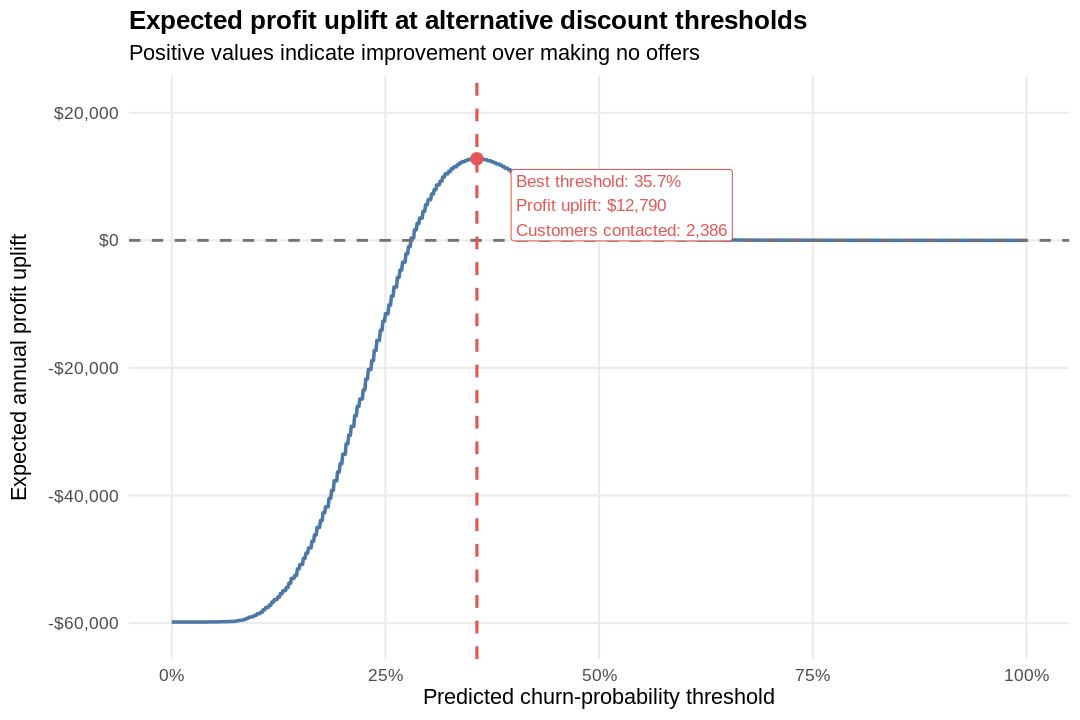


Decision optimisation is complete. The sensitivity analysis, scenario comparison, customer recommendations, and PNG charts have been saved.


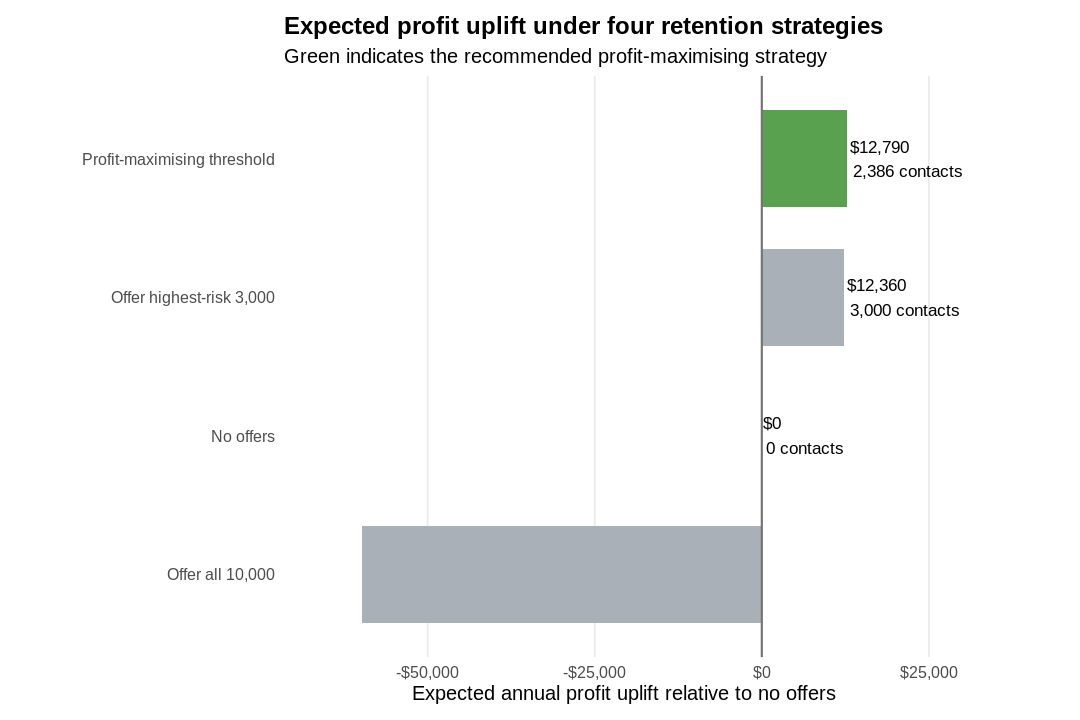

In [13]:
# =============================================================================
# COMM3501 A4 - 5. Decision Optimisation (R / Google Colab)
# =============================================================================
# AI use disclosure: OpenAI Codex was used for boilerplate generation,
# Run Step 4 before this section. This section uses concepts covered in the
# course: expected profit, scenario comparison, sensitivity analysis, and a
# simple decision table. It does not use a separate optimisation package.


# 1. Packages and Step 4 results -------------------------------------------
required_packages <- c("dplyr", "ggplot2", "scales")

missing_packages <- required_packages[
  !vapply(required_packages, requireNamespace, logical(1), quietly = TRUE)
]

if (length(missing_packages) > 0) {
  install.packages(missing_packages, repos = "https://cloud.r-project.org")
}

suppressPackageStartupMessages({
  library(dplyr)
  library(ggplot2)
  library(scales)
})

options(stringsAsFactors = FALSE, scipen = 999)
options(repr.plot.width = 9, repr.plot.height = 6, repr.plot.res = 120)

if (exists("evaluation_scores", envir = .GlobalEnv, inherits = FALSE) &&
    is.data.frame(evaluation_scores)) {
  decision_data <- evaluation_scores
  cat("Using evaluation probabilities created in Step 4.\n")
} else if (file.exists("stochastic_evaluation_customer_scores.csv")) {
  decision_data <- read.csv(
    "stochastic_evaluation_customer_scores.csv",
    stringsAsFactors = FALSE,
    check.names = FALSE
  )
  cat("Using stochastic_evaluation_customer_scores.csv from Step 4.\n")
} else {
  stop("Step 4 results were not found. Run Step 4 first.")
}

required_columns <- c(
  "CustomerID", "MonthlyRevenue",
  "Predicted_Churn_Probability", "Risk_Rank"
)
missing_columns <- setdiff(required_columns, names(decision_data))

if (length(missing_columns) > 0) {
  stop(paste(
    "Step 4 results are missing:",
    paste(missing_columns, collapse = ", ")
  ))
}

if (anyNA(decision_data[, required_columns])) {
  stop("Missing values were found in the required decision variables.")
}


# 2. Calculate expected profit for each customer ---------------------------
# Let p be predicted churn probability and R be annual revenue.
#
# No offer:
#   expected profit = (1 - p) * 0.15R
#
# Offer a 5% discount:
#   churn probability becomes 0.1p
#   expected profit = (1 - 0.1p) * 0.10R
decision_data <- decision_data %>%
  arrange(Risk_Rank) %>%
  mutate(
    Annual_Revenue = 12 * MonthlyRevenue,
    Expected_Profit_No_Offer =
      (1 - Predicted_Churn_Probability) * 0.15 * Annual_Revenue,
    Expected_Profit_With_Offer =
      (1 - 0.1 * Predicted_Churn_Probability) * 0.10 * Annual_Revenue,
    Expected_Profit_Uplift =
      Expected_Profit_With_Offer - Expected_Profit_No_Offer
  )

baseline_profit <- sum(decision_data$Expected_Profit_No_Offer)

# The two expected-profit expressions are equal when p = 0.05 / 0.14.
# This provides a theoretical break-even threshold of approximately 35.7%.
theoretical_threshold <- 0.05 / 0.14


# 3. Simple threshold sensitivity analysis ---------------------------------
# Test thresholds from 0% to 100% in steps of 0.1 percentage points.
# At each threshold, offer the discount to customers above the threshold and
# calculate total expected profit. This is a transparent scenario comparison.
threshold_values <- seq(0, 1, by = 0.001)

threshold_sensitivity <- data.frame(
  Probability_Threshold = threshold_values,
  Customers_Contacted = integer(length(threshold_values)),
  Expected_Total_Profit = numeric(length(threshold_values))
)

for (i in seq_along(threshold_values)) {
  current_threshold <- threshold_values[i]
  offer_discount <-
    decision_data$Predicted_Churn_Probability > current_threshold

  threshold_sensitivity$Customers_Contacted[i] <- sum(offer_discount)
  threshold_sensitivity$Expected_Total_Profit[i] <- sum(
    ifelse(
      offer_discount,
      decision_data$Expected_Profit_With_Offer,
      decision_data$Expected_Profit_No_Offer
    )
  )
}

threshold_sensitivity <- threshold_sensitivity %>%
  mutate(
    Expected_Profit_Uplift = Expected_Total_Profit - baseline_profit
  )

best_row <- which.max(threshold_sensitivity$Expected_Total_Profit)
recommended_threshold <-
  threshold_sensitivity$Probability_Threshold[best_row]
recommended_total_profit <-
  threshold_sensitivity$Expected_Total_Profit[best_row]
recommended_profit_uplift <-
  threshold_sensitivity$Expected_Profit_Uplift[best_row]

recommended_action <-
  decision_data$Predicted_Churn_Probability > recommended_threshold
recommended_contact_count <- sum(recommended_action)


# 4. Compare four understandable business scenarios ------------------------
top_3000_action <- decision_data$Risk_Rank <= 3000

evaluate_strategy <- function(strategy_name, action) {
  total_profit <- sum(
    ifelse(
      action,
      decision_data$Expected_Profit_With_Offer,
      decision_data$Expected_Profit_No_Offer
    )
  )

  data.frame(
    Strategy = strategy_name,
    Customers_Contacted = sum(action),
    Expected_Total_Profit = total_profit,
    Expected_Profit_Uplift = total_profit - baseline_profit,
    stringsAsFactors = FALSE
  )
}

strategy_comparison <- bind_rows(
  evaluate_strategy("No offers", rep(FALSE, nrow(decision_data))),
  evaluate_strategy("Offer all 10,000", rep(TRUE, nrow(decision_data))),
  evaluate_strategy("Offer highest-risk 3,000", top_3000_action),
  evaluate_strategy("Profit-maximising threshold", recommended_action)
) %>%
  mutate(
    Recommended = Strategy == "Profit-maximising threshold"
  )


# 5. Save the numerical results --------------------------------------------
decision_customer_actions <- decision_data %>%
  mutate(
    Recommend_Discount = recommended_action,
    Expected_Profit_Selected_Action = ifelse(
      Recommend_Discount,
      Expected_Profit_With_Offer,
      Expected_Profit_No_Offer
    )
  )

discount_recommendations <- decision_customer_actions %>%
  filter(Recommend_Discount) %>%
  select(
    CustomerID, Risk_Rank, Predicted_Churn_Probability,
    MonthlyRevenue, Expected_Profit_Uplift
  )

decision_summary <- data.frame(
  Metric = c(
    "Theoretical break-even threshold",
    "Profit-maximising threshold from sensitivity analysis",
    "Recommended customers to contact",
    "Expected profit with no offers",
    "Expected profit under recommended strategy",
    "Expected profit uplift",
    "Expected profit uplift percentage"
  ),
  Value = c(
    theoretical_threshold,
    recommended_threshold,
    recommended_contact_count,
    baseline_profit,
    recommended_total_profit,
    recommended_profit_uplift,
    recommended_profit_uplift / abs(baseline_profit)
  ),
  stringsAsFactors = FALSE
)

write.csv(
  threshold_sensitivity,
  "decision_threshold_sensitivity.csv",
  row.names = FALSE
)
write.csv(
  strategy_comparison,
  "decision_strategy_comparison.csv",
  row.names = FALSE
)
write.csv(
  decision_customer_actions,
  "decision_all_customer_actions.csv",
  row.names = FALSE
)
write.csv(
  discount_recommendations,
  "decision_discount_recommendations.csv",
  row.names = FALSE
)
write.csv(
  decision_summary,
  "decision_optimisation_summary.csv",
  row.names = FALSE
)


# 6. Display a concise summary ---------------------------------------------
cat("\nDecision optimisation summary:\n")
cat(
  "Theoretical break-even threshold:",
  scales::percent(theoretical_threshold, accuracy = 0.1), "\n"
)
cat(
  "Profit-maximising threshold:",
  scales::percent(recommended_threshold, accuracy = 0.1), "\n"
)
cat(
  "Recommended customers to contact:",
  scales::comma(recommended_contact_count), "\n"
)
cat(
  "Expected profit with no offers:",
  scales::dollar(baseline_profit, accuracy = 1), "\n"
)
cat(
  "Expected profit under the recommended strategy:",
  scales::dollar(recommended_total_profit, accuracy = 1), "\n"
)
cat(
  "Expected profit uplift:",
  scales::dollar(recommended_profit_uplift, accuracy = 1),
  paste0(
    " (",
    scales::percent(
      recommended_profit_uplift / abs(baseline_profit),
      accuracy = 0.01
    ),
    ")\n"
  )
)

cat("\nStrategy comparison:\n")
strategy_display <- strategy_comparison %>%
  mutate(
    Expected_Total_Profit = scales::dollar(
      Expected_Total_Profit, accuracy = 1
    ),
    Expected_Profit_Uplift = scales::dollar(
      Expected_Profit_Uplift, accuracy = 1
    )
  )
print(as.data.frame(strategy_display), row.names = FALSE)


# 7. Required and easy-to-read profit sensitivity chart --------------------
# Showing profit uplift makes the decision meaning clear:
# values above zero outperform the no-offer strategy.
best_plot_point <- threshold_sensitivity[best_row, ]

plot_profit_sensitivity <- ggplot(
  threshold_sensitivity,
  aes(x = Probability_Threshold, y = Expected_Profit_Uplift)
) +
  geom_line(colour = "#4C78A8", linewidth = 1) +
  geom_hline(
    yintercept = 0,
    colour = "grey45",
    linetype = "dashed",
    linewidth = 0.8
  ) +
  geom_vline(
    xintercept = recommended_threshold,
    colour = "#E45756",
    linetype = "dashed",
    linewidth = 0.9
  ) +
  geom_point(
    data = best_plot_point,
    colour = "#E45756",
    size = 3
  ) +
  annotate(
    "label",
    x = min(recommended_threshold + 0.04, 0.72),
    y = recommended_profit_uplift,
    label = paste0(
      "Best threshold: ",
      scales::percent(recommended_threshold, accuracy = 0.1),
      "\nProfit uplift: ",
      scales::dollar(recommended_profit_uplift, accuracy = 1),
      "\nCustomers contacted: ",
      scales::comma(recommended_contact_count)
    ),
    hjust = 0,
    vjust = 1.15,
    colour = "#E45756",
    fill = "white",
    size = 3.6
  ) +
  scale_x_continuous(
    labels = scales::percent_format(accuracy = 1),
    breaks = seq(0, 1, by = 0.25),
    limits = c(0, 1)
  ) +
  scale_y_continuous(
    labels = scales::dollar_format(),
    expand = expansion(mult = c(0.08, 0.18))
  ) +
  labs(
    title = "Expected profit uplift at alternative discount thresholds",
    subtitle = "Positive values indicate improvement over making no offers",
    x = "Predicted churn-probability threshold",
    y = "Expected annual profit uplift"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title = element_text(face = "bold"),
    panel.grid.minor = element_blank()
  )

print(plot_profit_sensitivity)
ggsave(
  "decision_01_profit_threshold_sensitivity.png",
  plot_profit_sensitivity,
  width = 9,
  height = 6,
  dpi = 300
)


# 8. Scenario comparison chart --------------------------------------------
strategy_plot_data <- strategy_comparison %>%
  mutate(
    Strategy = factor(
      Strategy,
      levels = Strategy[order(Expected_Total_Profit)]
    )
  )

plot_strategy_comparison <- ggplot(
  strategy_plot_data,
  aes(x = Strategy, y = Expected_Profit_Uplift, fill = Recommended)
) +
  geom_col(width = 0.7) +
  geom_hline(yintercept = 0, colour = "grey45", linewidth = 0.6) +
  geom_text(
    aes(
      label = paste0(
        scales::dollar(Expected_Profit_Uplift, accuracy = 1),
        "\n", scales::comma(Customers_Contacted), " contacts"
      )
    ),
    hjust = ifelse(
      strategy_plot_data$Expected_Profit_Uplift >= 0,
      -0.05,
      1.05
    ),
    colour = ifelse(
      strategy_plot_data$Expected_Profit_Uplift >= 0,
      "black",
      "white"
    ),
    size = 3.6
  ) +
  coord_flip(clip = "off") +
  scale_fill_manual(
    values = c("FALSE" = "#A9B0B7", "TRUE" = "#59A14F"),
    guide = "none"
  ) +
  scale_y_continuous(
    labels = scales::dollar_format(),
    expand = expansion(mult = c(0.16, 0.24))
  ) +
  labs(
    title = "Expected profit uplift under four retention strategies",
    subtitle = "Green indicates the recommended profit-maximising strategy",
    x = NULL,
    y = "Expected annual profit uplift relative to no offers"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold"),
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank(),
    plot.margin = ggplot2::margin(10, 70, 10, 10)
  )

print(plot_strategy_comparison)
ggsave(
  "decision_02_strategy_comparison.png",
  plot_strategy_comparison,
  width = 10,
  height = 6.5,
  dpi = 300
)

cat(
  "\nDecision optimisation is complete. The sensitivity analysis,",
  "scenario comparison, customer recommendations, and PNG charts",
  "have been saved.\n"
)